# Perceptron, RNN e LSTM

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Nas duas aulas anteriores usamos árvores. O trabalho pesado ficava por nossa conta: nós escrevíamos as colunas `variacao_lag1`, `media_variacao_3m`, `hora`, `eh_feriado`, e o modelo aprendia regras sobre elas. O modelo era esperto; a **representação** do problema era nossa.

Redes neurais invertem essa divisão de trabalho. Em vez de receber o passado resumido em colunas que escolhemos, uma rede recorrente recebe a **sequência inteira** e aprende sozinha quais pedaços do passado importam. Isso se chama **aprendizado de representação**, e é a razão pela qual essa família domina áudio, texto e vídeo.

Esta aula constrói o caminho completo, do menor elemento até a arquitetura moderna:

$$ \text{neurônio} \;\longrightarrow\; \text{perceptron} \;\longrightarrow\; \text{rede densa (MLP)} \;\longrightarrow\; \text{RNN} \;\longrightarrow\; \text{LSTM} $$

E vamos fazer isso de uma forma diferente das aulas anteriores: **implementando tudo do zero, em NumPy puro**. Nada de TensorFlow, nada de PyTorch. O motivo é didático e prático ao mesmo tempo. Didático porque os três portões da LSTM só param de ser mágica quando você vê as seis linhas de código que os calculam. Prático porque assim o notebook roda em qualquer ambiente, sem instalar bibliotecas pesadas nem depender de versão de Python.

Vamos escrever, do zero:

- a **propagação para frente** (o cálculo da previsão);
- a **retropropagação** (o cálculo dos gradientes, inclusive através do tempo);
- o otimizador **Adam**;
- e uma **checagem numérica de gradiente**, que é como se prova que a implementação está correta.

**Caso de estudo:** voltamos ao **volume horário de ligações na central de atendimento**, agora com **dois anos** de história e um ingrediente novo e decisivo: **ondas epidemiológicas**. Surtos de síndrome gripal aparecem de forma episódica, elevam o volume por **semanas** e decaem devagar. Esse é um **estado latente**: ele não está em nenhuma coluna de calendário, e a única forma de percebê-lo é olhar o comportamento recente da série. É exatamente o tipo de estrutura em que uma rede com memória tem algo a oferecer.

**Ao final desta aula você será capaz de:**

1. Escrever a equação de um neurônio artificial e explicar o papel da função de ativação.
2. Treinar um perceptron por descida de gradiente e **interpretar os pesos aprendidos**.
3. Explicar por que uma rede densa **ignora a ordem** dos dados, e demonstrar isso experimentalmente.
4. Implementar uma RNN e entender a retropropagação através do tempo.
5. Demonstrar, com números, o **gradiente que desaparece**.
6. Implementar uma célula LSTM, inspecionar seus **três portões** e mostrar onde ela vence a RNN.
7. Comparar todas as arquiteturas contra o **piso de erro** do problema e discutir custo e benefício de forma honesta.

**Como usar este material:** execute as células na ordem. Depois de cada saída há um bloco **Lendo o resultado**. Alguns treinamentos levam alguns segundos (a LSTM leva cerca de meio minuto), e isso faz parte da lição.


## 0. Preparação do ambiente

A célula abaixo carrega apenas **NumPy, pandas e matplotlib**. Não há nenhuma biblioteca de deep learning envolvida nesta aula.


In [1]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "ipywidgets"])

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11
print("Ambiente pronto. Tudo o que vem a seguir e NumPy puro.")

Ambiente pronto. Tudo o que vem a seguir e NumPy puro.


## O laboratório: dois anos de central de atendimento, com ondas epidemiológicas

Como sempre, construímos a série para saber o que colocamos dentro dela. São **730 dias hora a hora**, ou seja, **17.520 observações**, de janeiro de 2024 a dezembro de 2025. Os ingredientes:

| Componente                                    | Escala de tempo   | Está em alguma coluna de calendário? |
| --------------------------------------------- | ----------------- | ------------------------------------ |
| Perfil horário (pico da manhã, almoço, tarde) | 24 horas          | sim, a hora do dia                   |
| Perfil semanal (segunda cheia, domingo vazio) | 7 dias            | sim, o dia da semana                 |
| Feriados nacionais                            | pontual           | sim, uma indicadora                  |
| Sazonalidade anual (inverno)                  | 12 meses          | sim, o dia do ano                    |
| **Nível local AR(1)**                         | **poucas horas**  | **não**                              |
| **Ondas epidemiológicas**                     | **2 a 6 semanas** | **não**                              |
| Ruído de observação                           | instantâneo       | não, e é imprevisível                |

As duas linhas em destaque são o coração da aula. O **nível local** é uma persistência de curto prazo: se as últimas horas vieram acima do esperado, a próxima provavelmente também virá. A **onda epidemiológica** é um estado que se instala de repente, eleva o volume por semanas e decai devagar, com efeito mais forte no horário de pico (quem está doente liga em horário comercial).

Nenhum dos dois aparece no calendário. Um modelo que só conheça hora, dia e feriado está estruturalmente cego para eles. Já um modelo que receba as **últimas 48 horas da série** pode inferir: "o nível está alto há dias, provavelmente estamos em um surto".


In [2]:
PERFIL_HORARIO = np.array([-8, -9, -9, -9, -8, -6, -3, 1, 5, 8, 9, 8,
                           3, 2, 7, 8, 6, 3, -1, -3, -4, -5, -6, -7], dtype=float)
PERFIL_SEMANAL = np.array([3, 1, 0, 1, 2, -2, -3], dtype=float)

FERIADOS = pd.to_datetime([
    "2024-01-01", "2024-02-12", "2024-02-13", "2024-03-29", "2024-04-21", "2024-05-01",
    "2024-05-30", "2024-09-07", "2024-10-12", "2024-11-02", "2024-11-15", "2024-11-20", "2024-12-25",
    "2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18", "2025-04-21", "2025-05-01", "2025-06-19",
    "2025-09-07", "2025-10-12", "2025-11-02", "2025-11-15", "2025-11-20", "2025-12-25"])


def gerar_central(dias=730, semente=SEMENTE):
    """Gera 2 anos de volume horario de ligacoes, com estado latente epidemiologico."""
    g = np.random.default_rng(semente)
    n = dias * 24
    indice = pd.date_range("2024-01-01", periods=n, freq="h")
    hora = indice.hour.to_numpy()
    dia_semana = indice.dayofweek.to_numpy()
    dia_do_ano = indice.dayofyear.to_numpy()
    dia = np.arange(n) // 24
    feriado = np.isin(indice.normalize(), FERIADOS).astype(float)

    # Sazonalidade anual: inverno concentra doenca respiratoria
    anual = 3.2 * np.sin(2 * np.pi * (dia_do_ano - 40) / 365)

    # Ondas epidemiologicas: estado latente que salta e decai devagar (semanas)
    surto_diario = np.zeros(dias)
    estado = 0.0
    for d in range(dias):
        if g.random() < 0.012:            # comeco de surto, cerca de 4 por ano
            estado += g.uniform(4, 9)
        estado *= 0.93                    # decaimento lento
        surto_diario[d] = estado
    surto = surto_diario[dia]

    # Nivel local AR(1) hora a hora: persistencia de curto prazo
    nivel_local = np.zeros(n)
    choque = g.normal(0, 1.1, n)
    for t in range(1, n):
        nivel_local[t] = 0.82 * nivel_local[t - 1] + choque[t]

    sinal = (24 + 0.004 * dia                       # nivel e tendencia
             + PERFIL_HORARIO[hora]                 # ciclo diario
             + PERFIL_SEMANAL[dia_semana]           # ciclo semanal
             + anual                                # sazonalidade anual
             + surto * (1 + 0.35 * (PERFIL_HORARIO[hora] > 3))   # surto, mais forte no pico
             - 11 * feriado
             + nivel_local)

    observado = np.clip(np.round(sinal + g.normal(0, 1.5, n)), 0, None)
    return pd.DataFrame({"n_ligacoes": observado, "sinal": sinal, "eh_feriado": feriado,
                         "surto": surto, "onda_anual": anual}, index=indice)


central = gerar_central()

print(f"Observacoes: {len(central)}  ({central.index.min():%d/%m/%Y} a {central.index.max():%d/%m/%Y})")
print(f"Media: {central.n_ligacoes.mean():.1f} ligacoes/hora   |   desvio-padrao: {central.n_ligacoes.std():.1f}")
print(f"Dias sob efeito de surto (estado > 1): {int((central.surto > 1).sum() / 24)} de {len(central)//24}")
print(f"Ruido de observacao: desvio-padrao 1,5 ligacao  ->  este e o limite de precisao do problema")
central.head(3)

Observacoes: 17520  (01/01/2024 a 30/12/2025)
Media: 25.3 ligacoes/hora   |   desvio-padrao: 7.8
Dias sob efeito de surto (estado > 1): 141 de 730
Ruido de observacao: desvio-padrao 1,5 ligacao  ->  este e o limite de precisao do problema


,n_ligacoes,sinal,eh_feriado,surto,onda_anual
2024-01-01 00:00:00,7.0,6.009450,1.0,0.0,-1.99055
2024-01-01 01:00:00,6.0,6.456756,1.0,0.0,-1.99055
2024-01-01 02:00:00,3.0,6.028214,1.0,0.0,-1.99055


> **Lendo o resultado.** São **17.520 horas** de operação, com média de **25,3 ligações por hora** e desvio-padrão de **7,8**. Em **141 dos 730 dias** houve alguma onda epidemiológica ativa, o que é razoável para uma operadora real: surtos não são a regra, mas também não são exceção.
>
> A última linha antecipa a régua desta aula. O ruído de observação tem desvio-padrão de **1,5 ligação**, e para um erro gaussiano o MAE mínimo teórico é cerca de $0{,}8\sigma$, ou seja, aproximadamente **1,2 ligação por hora**. Como guardamos a coluna `sinal` (o valor antes do ruído), poderemos calcular esse **piso** exatamente e comparar cada arquitetura com ele.


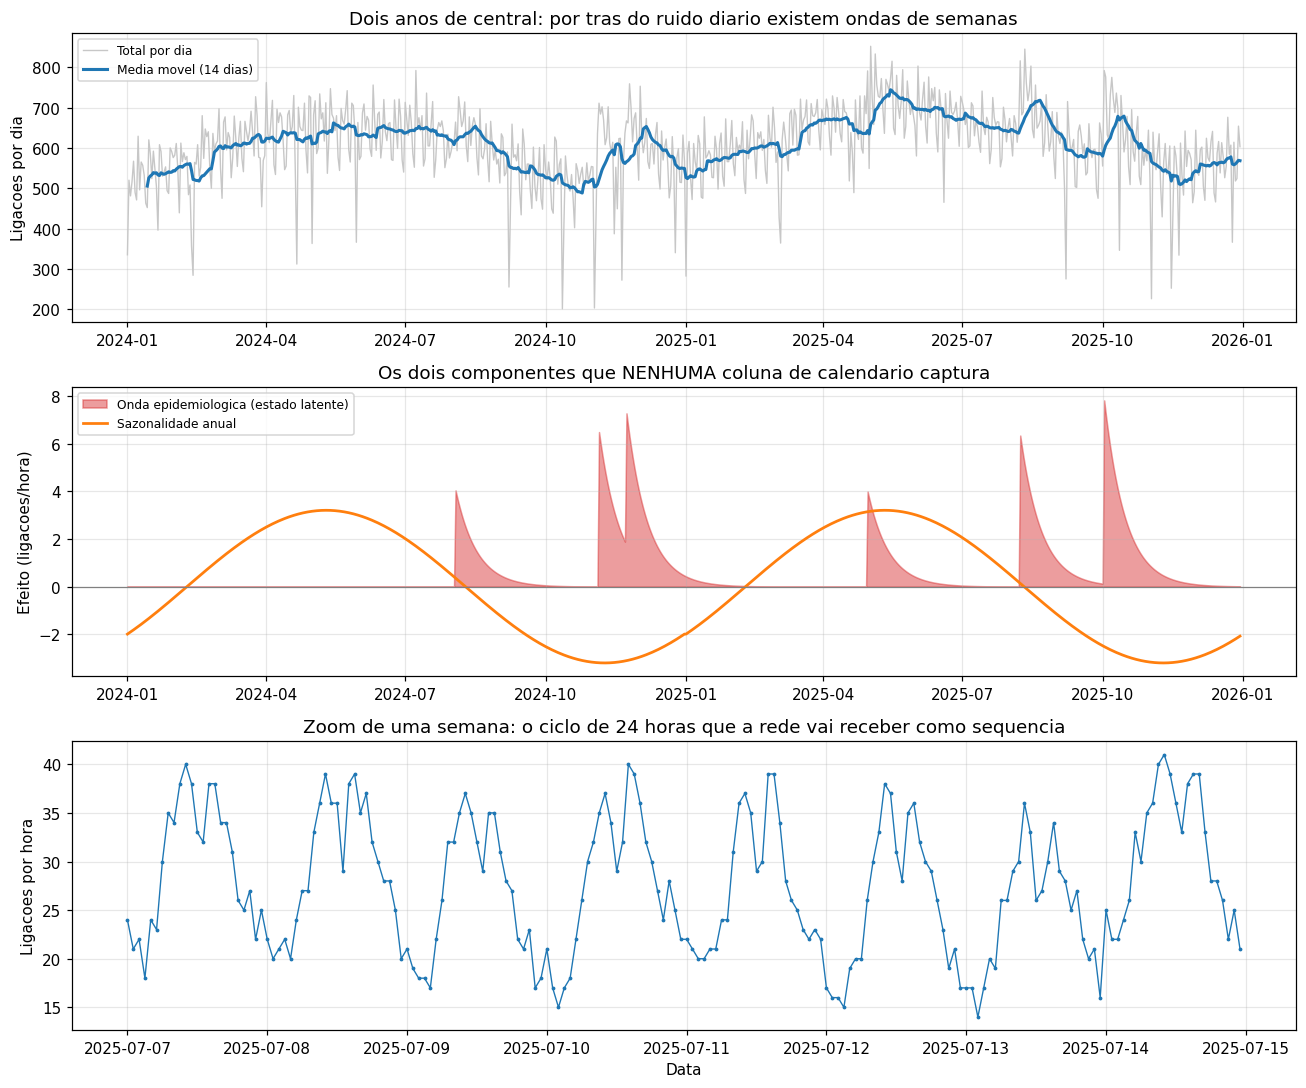

Surto mais forte da serie: 02/10/2025, com efeito de +7.8 ligacoes/hora no nivel base


In [3]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

diario = central["n_ligacoes"].resample("D").sum()
ax1.plot(diario.index, diario.values, color="#c7c7c7", lw=0.9, label="Total por dia")
ax1.plot(diario.index, diario.rolling(14).mean(), color="#1f77b4", lw=2, label="Media movel (14 dias)")
ax1.set_title("Dois anos de central: por tras do ruido diario existem ondas de semanas")
ax1.set_ylabel("Ligacoes por dia"); ax1.legend(fontsize=8)

surto_dia = central["surto"].resample("D").mean()
anual_dia = central["onda_anual"].resample("D").mean()
ax2.fill_between(surto_dia.index, 0, surto_dia.values, color="#d62728", alpha=0.45,
                 label="Onda epidemiologica (estado latente)")
ax2.plot(anual_dia.index, anual_dia.values, color="#ff7f0e", lw=1.8, label="Sazonalidade anual")
ax2.axhline(0, color="gray", lw=0.8)
ax2.set_title("Os dois componentes que NENHUMA coluna de calendario captura")
ax2.set_ylabel("Efeito (ligacoes/hora)"); ax2.legend(fontsize=8)

zoom = central.loc["2025-07-07":"2025-07-14", "n_ligacoes"]
ax3.plot(zoom.index, zoom.values, color="#1f77b4", marker=".", ms=3, lw=0.9)
ax3.set_title("Zoom de uma semana: o ciclo de 24 horas que a rede vai receber como sequencia")
ax3.set_ylabel("Ligacoes por hora"); ax3.set_xlabel("Data")

plt.tight_layout(); plt.show()

pico_surto = central["surto"].idxmax()
print(f"Surto mais forte da serie: {pico_surto:%d/%m/%Y}, com efeito de "
      f"+{central['surto'].max():.1f} ligacoes/hora no nivel base")

> **Lendo os gráficos.** O painel de cima mostra o total diário em cinza e a média móvel de 14 dias em azul. A média móvel não é plana nem puramente sazonal: ela tem **platôs e corcovas** que duram semanas. Essas corcovas são as ondas epidemiológicas.
>
> O painel do meio isola exatamente os dois componentes invisíveis ao calendário. A área vermelha é o **estado latente de surto**, que salta de repente e decai por semanas, chegando a somar mais de **7 ligações por hora** no pico da série. A linha laranja é a sazonalidade anual, mais suave e previsível. Compare os dois: a onda anual **é** deduzível do calendário (basta saber o mês), mas o surto **não é**. Nenhum modelo pode adivinhar quando um surto começa; o que um bom modelo pode fazer é **perceber que ele já começou** e ajustar a previsão. Perceber isso exige olhar o passado recente, e é essa a competência que vamos construir.
>
> O painel de baixo é o zoom de uma semana, hora a hora. É este o formato que entra na rede: não uma tabela de features, e sim **uma sequência**.


## 9.1 O neurônio artificial

> **Definição.** Um **neurônio artificial** recebe várias entradas, calcula uma **soma ponderada** delas, acrescenta um deslocamento e passa o resultado por uma **função de ativação**.

Em duas linhas de matemática:

$$ z \;=\; \sum\_{j=1}^{p} w_j x_j \;+\; b \;=\; \mathbf{w}^\top \mathbf{x} + b \qquad\qquad a \;=\; \varphi(z) $$

Cada peso $w_j$ diz **quanto** aquela entrada importa e em que **direção**: positivo empurra a saída para cima, negativo para baixo. O termo $b$ (viés, ou _bias_) desloca a resposta, permitindo que o neurônio não seja obrigado a passar pela origem. E a função $\varphi$ é o que decide se o neurônio é linear ou não.

O **perceptron**, proposto por Rosenblatt em 1958, é exatamente isso: **um único neurônio**. Vale registrar um fato que costuma surpreender: um neurônio com $\varphi(z) = z$ (ativação identidade) **é** uma regressão linear. Toda a diferença entre uma rede neural e uma regressão está em duas escolhas: usar uma ativação **não linear** e **empilhar** neurônios em camadas.

As três ativações usadas na prática:

| Ativação     | Fórmula                    | Saída         | Onde se usa                                                 |
| ------------ | -------------------------- | ------------- | ----------------------------------------------------------- |
| **Sigmoide** | $\sigma(z) = 1/(1+e^{-z})$ | entre 0 e 1   | **portões** da LSTM (quanto passar, de 0% a 100%)           |
| **Tanh**     | $\tanh(z)$                 | entre -1 e 1  | estado interno da RNN e da LSTM (pode aumentar ou diminuir) |
| **ReLU**     | $\max(0, z)$               | 0 ou positivo | camadas ocultas de redes profundas (barata e sem saturar)   |

A sigmoide merece atenção especial, porque é a peça que faz a LSTM funcionar: como ela **sempre devolve um número entre 0 e 1**, é o objeto matemático natural para representar uma **comporta**. Multiplicar uma informação por 0,03 é quase apagá-la; por 0,97, é deixá-la passar quase intacta.


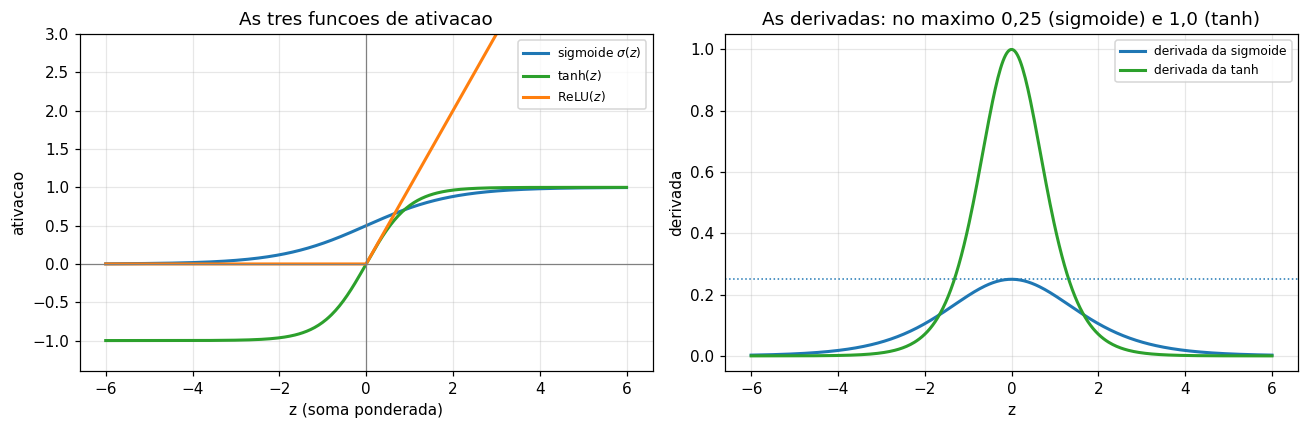

derivada maxima da sigmoide: 0.250  (em z = 0)
derivada maxima da tanh    : 1.000  (em z = 0)
derivada da tanh em z = 3  : 0.0099  ->  praticamente saturada


In [4]:
def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-6, 6, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(z, sigmoide(z), color="#1f77b4", lw=2, label=r"sigmoide $\sigma(z)$")
ax1.plot(z, np.tanh(z), color="#2ca02c", lw=2, label=r"tanh$(z)$")
ax1.plot(z, np.maximum(0, z), color="#ff7f0e", lw=2, label=r"ReLU$(z)$")
ax1.axhline(0, color="gray", lw=0.8); ax1.axvline(0, color="gray", lw=0.8)
ax1.set_ylim(-1.4, 3); ax1.set_title("As tres funcoes de ativacao")
ax1.set_xlabel("z (soma ponderada)"); ax1.set_ylabel("ativacao"); ax1.legend(fontsize=8)

# A derivada e o que viaja na retropropagacao: repare como ela SATURA
ax2.plot(z, sigmoide(z) * (1 - sigmoide(z)), color="#1f77b4", lw=2, label="derivada da sigmoide")
ax2.plot(z, 1 - np.tanh(z) ** 2, color="#2ca02c", lw=2, label="derivada da tanh")
ax2.axhline(0.25, color="#1f77b4", ls=":", lw=1)
ax2.set_title("As derivadas: no maximo 0,25 (sigmoide) e 1,0 (tanh)")
ax2.set_xlabel("z"); ax2.set_ylabel("derivada"); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"derivada maxima da sigmoide: {max(sigmoide(z) * (1 - sigmoide(z))):.3f}  (em z = 0)")
print(f"derivada maxima da tanh    : {max(1 - np.tanh(z) ** 2):.3f}  (em z = 0)")
print(f"derivada da tanh em z = 3  : {1 - np.tanh(3.0) ** 2:.4f}  ->  praticamente saturada")

> **Lendo os gráficos.** À esquerda, as três ativações. A **sigmoide** (azul) comprime qualquer número real em uma faixa de 0 a 1, com transição suave; a **tanh** (verde) faz o mesmo entre -1 e 1, permitindo saída negativa; a **ReLU** (laranja) simplesmente descarta o que é negativo.
>
> O gráfico da direita é o mais importante da seção, e você vai reencontrá-lo na Seção 9.3. Ele mostra as **derivadas**, e é a derivada que viaja na retropropagação, multiplicando os gradientes. Dois números para guardar: a derivada da sigmoide vale **no máximo 0,25**, e a da tanh **no máximo 1,0**. Fora da vizinhança de zero, ambas **saturam**: em $z = 3$ a derivada da tanh já é de apenas **0,0099**.
>
> Guarde essa consequência: cada camada, ou cada passo de tempo, multiplica o gradiente por um número tipicamente **menor do que 1**. Multiplique 30 números menores que 1 e você tem um gradiente que praticamente desapareceu. É este o mecanismo que limita as RNNs, e é para resolvê-lo que a LSTM existe.


## Montando o problema supervisionado: janelas de sequência

Uma rede recorrente não recebe uma tabela de features, recebe **sequências**. A transformação necessária se chama **janelamento** (_windowing_): percorremos a série e, para cada instante, empacotamos as últimas $J$ observações como entrada e o valor seguinte como alvo.

$$ \underbrace{[\,y_{t-48},\, y_{t-47},\, \ldots,\, y_{t-1}\,]}_{\text{entrada: uma janela de 48 horas}} \;\longrightarrow\; \underbrace{y_t}_{\text{alvo: a próxima hora}} $$

Usamos janela de **48 horas** (dois dias completos), o que dá à rede a chance de ver o ciclo diário se repetir dentro da própria entrada. Cada passo de tempo da janela carrega **6 canais**, e não apenas o valor:

| Canal | Conteúdo                        | Por que existe                                              |
| ----- | ------------------------------- | ----------------------------------------------------------- |
| 0     | volume de ligações              | o sinal principal                                           |
| 1, 2  | seno e cosseno da hora do dia   | codifica a hora de forma **circular** (23h é vizinha de 0h) |
| 3, 4  | seno e cosseno do dia da semana | mesma ideia para o ciclo semanal                            |
| 5     | indicadora de feriado           | quebra de comportamento conhecida de antemão                |

A codificação em seno e cosseno merece explicação, porque é uma técnica valiosa e pouco óbvia. Se déssemos a hora como número de 0 a 23, a rede aprenderia que 23h está **muito longe** de 0h, quando na verdade são horas vizinhas. Colocando o relógio em um círculo, $(\sin, \cos)$, essa vizinhança fica correta por construção.

Duas providências finais, e as duas são obrigatórias em redes neurais:

1. **Separação cronológica**: 70% para treino, 15% para validação e 15% para teste, na ordem do tempo.
2. **Normalização**: a rede recebe os valores em unidades de desvio-padrão, com média e desvio calculados **somente no treino**. Sem isso, as somas ponderadas entram na região saturada das ativações e o treinamento simplesmente não avança. Diferente das árvores, que são indiferentes à escala, redes neurais **exigem** essa etapa.


In [5]:
JANELA = 48

def montar_janelas(df, J=JANELA):
    """Transforma a serie em (n, J, 6): n exemplos, J passos de tempo, 6 canais."""
    valor = df["n_ligacoes"].values.astype(float)
    idx = df.index
    hora = idx.hour.to_numpy()
    dia_semana = idx.dayofweek.to_numpy()

    canais = np.stack([
        valor,
        np.sin(2 * np.pi * hora / 24), np.cos(2 * np.pi * hora / 24),
        np.sin(2 * np.pi * dia_semana / 7), np.cos(2 * np.pi * dia_semana / 7),
        df["eh_feriado"].values,
    ], axis=1)

    n = len(valor) - J
    X = np.stack([canais[i:i + J] for i in range(n)])
    y = valor[J:].reshape(-1, 1)
    sinal = df["sinal"].values[J:].reshape(-1, 1)      # so para calcular o piso do problema
    return X, y, sinal, idx[J:]


X, y, sinal, datas = montar_janelas(central)
n = len(X)
corte1, corte2 = int(0.70 * n), int(0.85 * n)

X_treino, X_val, X_teste = X[:corte1], X[corte1:corte2], X[corte2:]
y_treino, y_val, y_teste = y[:corte1], y[corte1:corte2], y[corte2:]

# Normalizacao do canal de valor, com estatisticas do TREINO apenas
media, desvio = X_treino[:, :, 0].mean(), X_treino[:, :, 0].std()

def normalizar(A):
    B = A.copy()
    B[:, :, 0] = (B[:, :, 0] - media) / desvio
    return B

N_treino, N_val, N_teste = normalizar(X_treino), normalizar(X_val), normalizar(X_teste)
z_treino, z_val = (y_treino - media) / desvio, (y_val - media) / desvio

# Versao achatada (48 x 6 = 288 numeros por exemplo) para as redes densas
F_treino, F_val, F_teste = [A.reshape(len(A), -1) for A in (N_treino, N_val, N_teste)]


def metricas(y_real, y_prev):
    """MAE, RMSE e MAPE em ligacoes por hora. Menor e melhor."""
    y_real = np.asarray(y_real, dtype=float).ravel()
    y_prev = np.asarray(y_prev, dtype=float).ravel()
    erro = y_real - y_prev
    return (np.mean(np.abs(erro)), np.sqrt(np.mean(erro ** 2)),
            np.mean(np.abs(erro / np.maximum(y_real, 1))) * 100)

def avaliar(previsao_normalizada):
    """Desfaz a normalizacao e mede contra o alvo real do teste."""
    return metricas(y_teste, previsao_normalizada * desvio + media)


print(f"Formato do tensor de entrada: {X.shape}  ->  (exemplos, passos de tempo, canais)")
print(f"TREINO {len(X_treino):6d}  ({datas[0]:%d/%m/%Y} a {datas[corte1-1]:%d/%m/%Y})")
print(f"VALID  {len(X_val):6d}  ({datas[corte1]:%d/%m/%Y} a {datas[corte2-1]:%d/%m/%Y})")
print(f"TESTE  {len(X_teste):6d}  ({datas[corte2]:%d/%m/%Y} a {datas[-1]:%d/%m/%Y})")
print(f"\nNormalizacao (do treino): media {media:.2f}, desvio {desvio:.2f}")
print()

referencias = pd.DataFrame([
    {"referencia": "Repetir a ultima hora (lag 1)", **dict(zip(("MAE", "RMSE", "MAPE (%)"),
        np.round(metricas(y_teste, X_teste[:, -1, 0]), 3)))},
    {"referencia": "Mesma hora de ontem (lag 24)", **dict(zip(("MAE", "RMSE", "MAPE (%)"),
        np.round(metricas(y_teste, X_teste[:, -24, 0]), 3)))},
    {"referencia": "ORACULO (o sinal sem ruido)", **dict(zip(("MAE", "RMSE", "MAPE (%)"),
        np.round(metricas(y_teste, sinal[corte2:]), 3)))},
])
referencias

Formato do tensor de entrada: (17472, 48, 6)  ->  (exemplos, passos de tempo, canais)
TREINO  12230  (03/01/2024 a 26/05/2025)
VALID    2621  (26/05/2025 a 12/09/2025)
TESTE    2621  (12/09/2025 a 30/12/2025)

Normalizacao (do treino): media 25.15, desvio 7.72



,referencia,MAE,RMSE,MAPE (%)
0,Repetir a ultima hora (lag 1),2.896,3.662,13.977
1,Mesma hora de ontem (lag 24),4.508,5.995,28.352
2,ORACULO (o sinal sem ruido),1.243,1.558,6.342


> **Lendo o resultado.** O tensor de entrada tem formato **(17.472, 48, 6)**: dezessete mil exemplos, cada um com 48 passos de tempo e 6 canais por passo. Essa é a forma canônica de dados sequenciais, e é bom se acostumar com ela porque é o que qualquer biblioteca de deep learning espera.
>
> As três referências delimitam o campo de jogo:
>
> - **Repetir a última hora** erra **2,90 ligações**. Note que essa é uma referência forte, muito melhor do que a média histórica, porque a série tem persistência de curto prazo.
> - **Mesma hora de ontem** erra **4,51**, bem pior. Isso é informativo: o ciclo diário **existe**, mas o valor de ontem no mesmo horário está contaminado por 24 horas de ruído e de movimento do nível. Copiar o passado distante é pior do que copiar o passado imediato.
> - O **oráculo**, que conhece o sinal exato antes do ruído, erra **1,24**. É o piso do problema.
>
> Todo o espaço de competência das redes está entre **2,90** e **1,24**, ou seja, **1,66 ligação** de margem. Vamos medir, para cada arquitetura, quanto dessa margem ela consegue capturar.


## Como o neurônio aprende: descida de gradiente e Adam

Treinar uma rede é resolver um problema de otimização. Definimos uma **função de perda**, aqui o erro quadrático médio,

$$ L(\mathbf{w}) \;=\; \frac{1}{n}\sum\_{i=1}^{n} \left( y_i - \hat{y}\_i(\mathbf{w}) \right)^2 $$

e procuramos os pesos que a minimizam. O método é a **descida de gradiente**: calcula-se a derivada da perda em relação a cada peso e caminha-se **contra** o gradiente,

$$ w \;\leftarrow\; w \;-\; \eta \, \frac{\partial L}{\partial w} $$

onde $\eta$ é a **taxa de aprendizado**. Três refinamentos, todos presentes no nosso código:

1. **Minilotes** (_mini-batches_). Em vez de usar todos os 12 mil exemplos por atualização, usamos 128 por vez. Fica mais rápido e o ruído das amostras ajuda a escapar de mínimos locais rasos. Uma passada por todos os dados é uma **época**.
2. **Retropropagação** (_backpropagation_). É a aplicação organizada da regra da cadeia, que calcula todas as derivadas em uma única passagem de trás para frente. Não é um algoritmo de otimização, é a forma eficiente de obter o gradiente.
3. **Adam** (Kingma e Ba, 2015). Em vez de um passo fixo, o Adam mantém uma média móvel do gradiente (o **momento**, que dá inércia) e uma média móvel do seu quadrado (a **escala**, que adapta o tamanho do passo a cada peso individualmente). É o otimizador padrão da prática, e implementá-lo são cinco linhas.


In [6]:
class Adam:
    """Otimizador Adam: momento (media do gradiente) + escala adaptativa (media do quadrado)."""

    def __init__(self, parametros, taxa=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.p = parametros
        self.taxa, self.b1, self.b2, self.eps = taxa, beta1, beta2, eps
        self.t = 0
        self.m = {k: np.zeros_like(v) for k, v in parametros.items()}   # momento
        self.v = {k: np.zeros_like(v) for k, v in parametros.items()}   # escala

    def passo(self, gradientes):
        self.t += 1
        for k in self.p:
            g = gradientes[k]
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * g
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * g * g
            m_corrigido = self.m[k] / (1 - self.b1 ** self.t)          # corrige o vies do inicio
            v_corrigido = self.v[k] / (1 - self.b2 ** self.t)
            self.p[k] -= self.taxa * m_corrigido / (np.sqrt(v_corrigido) + self.eps)


def treinar(modelo, Xtr, ytr, Xva, yva, epocas=15, lote=128, taxa=0.01,
            semente=SEMENTE, fotografias=()):
    """Laco de treinamento: minilotes, retropropagacao e Adam. Devolve o historico da perda."""
    otimizador = Adam(modelo.p, taxa=taxa)
    g = np.random.default_rng(semente)
    historico, fotos = [], {}

    for epoca in range(1, epocas + 1):
        ordem = g.permutation(len(Xtr))                     # embaralha os EXEMPLOS, nao o tempo
        for k in range(0, len(Xtr), lote):
            idx = ordem[k:k + lote]
            Xb, yb = Xtr[idx], ytr[idx]
            previsto, cache = modelo.frente(Xb)             # propagacao para frente
            gradientes = modelo.tras(Xb, yb, previsto, cache)   # retropropagacao
            otimizador.passo(gradientes)                    # atualizacao dos pesos

        perda_tr = float(np.mean((ytr - modelo.frente(Xtr)[0]) ** 2))
        perda_va = float(np.mean((yva - modelo.frente(Xva)[0]) ** 2))
        historico.append((epoca, perda_tr, perda_va))
        if epoca in fotografias:
            fotos[epoca] = {k: v.copy() for k, v in modelo.p.items()}

    return historico, fotos


print("Adam e laco de treinamento definidos.")
print("Repare no detalhe da linha do permutation: embaralhamos a ordem dos EXEMPLOS entre epocas,")
print("o que e correto e ate desejavel. O que nunca se embaralha e a ordem do TEMPO dentro da janela.")

Adam e laco de treinamento definidos.
Repare no detalhe da linha do permutation: embaralhamos a ordem dos EXEMPLOS entre epocas,
o que e correto e ate desejavel. O que nunca se embaralha e a ordem do TEMPO dentro da janela.


### O perceptron em código, e os pesos que ele aprende

A classe abaixo implementa as duas primeiras arquiteturas de uma vez. Com `n_oculto = 0` ela é um **perceptron** (um neurônio linear); com `n_oculto > 0` ela é uma **rede densa com uma camada oculta**, o clássico **MLP** (_Multi-Layer Perceptron_).

Repare no método `tras`: são quatro linhas que implementam a regra da cadeia. Para o MLP,

$$ \frac{\partial L}{\partial W_2} = a^\top \delta, \qquad \delta_a = (\delta\, W_2^\top) \odot (1 - a^2), \qquad \frac{\partial L}{\partial W_1} = X^\top \delta_a $$

em que $\delta$ é o erro na saída e $(1 - a^2)$ é a derivada da tanh. É literalmente isso que qualquer biblioteca de deep learning faz, só que com mais camadas e mais engenharia.


Perceptron: 289 parametros treinaveis, 0.1s de treinamento
  MAE 2.068  |  RMSE 2.650  |  MAPE 11.52%
  para comparar: repetir a ultima hora da MAE 2,896  |  piso do oraculo 1,243


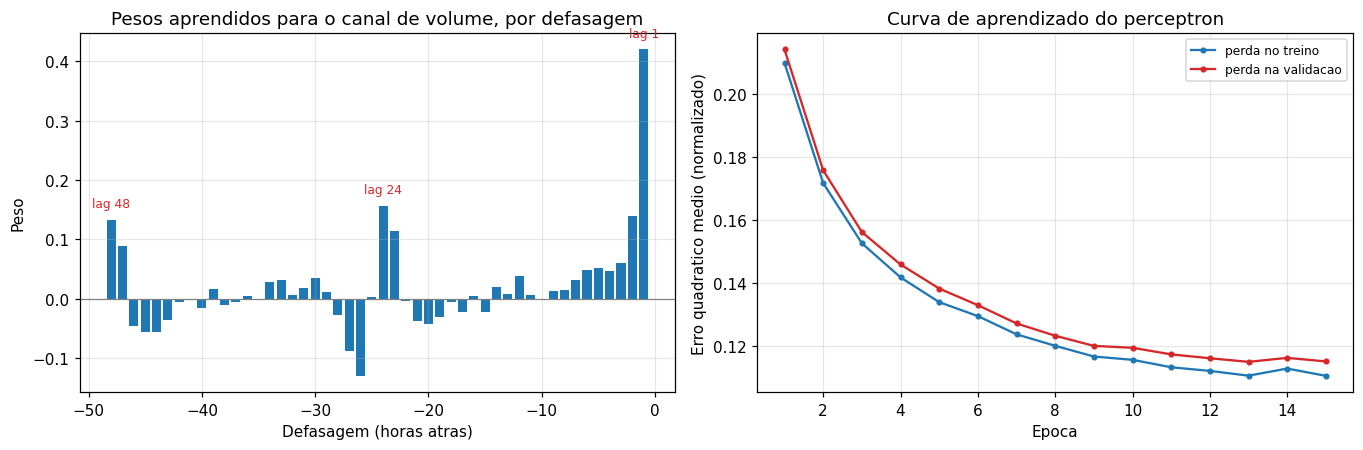


Tres maiores pesos (em modulo) do canal de volume:
  defasagem de  1 hora(s): peso +0.420
  defasagem de 24 hora(s): peso +0.157
  defasagem de  2 hora(s): peso +0.139


In [7]:
class RedeDensa:
    """n_oculto = 0  ->  perceptron (um neuronio linear, equivalente a regressao linear).
       n_oculto > 0  ->  MLP com uma camada oculta de ativacao tanh."""

    def __init__(self, n_entrada, n_oculto=0, semente=SEMENTE):
        g = np.random.default_rng(semente)
        self.n_oculto = n_oculto
        if n_oculto == 0:
            self.p = {"W": g.normal(0, 0.05, (n_entrada, 1)), "b": np.zeros((1, 1))}
        else:
            # Inicializacao com escala 1/sqrt(entradas): mantem as somas ponderadas fora da saturacao
            self.p = {"W1": g.normal(0, np.sqrt(1 / n_entrada), (n_entrada, n_oculto)),
                      "b1": np.zeros((1, n_oculto)),
                      "W2": g.normal(0, np.sqrt(1 / n_oculto), (n_oculto, 1)),
                      "b2": np.zeros((1, 1))}

    def frente(self, X):
        if self.n_oculto == 0:
            return X @ self.p["W"] + self.p["b"], {}
        a = np.tanh(X @ self.p["W1"] + self.p["b1"])        # camada oculta
        return a @ self.p["W2"] + self.p["b2"], {"a": a}    # saida linear

    def tras(self, X, y, previsto, cache):
        n = len(X)
        d = (previsto - y) * 2.0 / n                        # derivada do erro quadratico medio
        if self.n_oculto == 0:
            return {"W": X.T @ d, "b": d.sum(0, keepdims=True)}
        a = cache["a"]
        da = (d @ self.p["W2"].T) * (1 - a ** 2)            # regra da cadeia pela tanh
        return {"W1": X.T @ da, "b1": da.sum(0, keepdims=True),
                "W2": a.T @ d, "b2": d.sum(0, keepdims=True)}


inicio = time.time()
perceptron = RedeDensa(F_treino.shape[1], n_oculto=0)
hist_perc, _ = treinar(perceptron, F_treino, z_treino, F_val, z_val, epocas=15, taxa=0.001)
tempo_perc = time.time() - inicio

mae_perc, rmse_perc, mape_perc = avaliar(perceptron.frente(F_teste)[0])
n_par_perc = sum(v.size for v in perceptron.p.values())

print(f"Perceptron: {n_par_perc} parametros treinaveis, {tempo_perc:.1f}s de treinamento")
print(f"  MAE {mae_perc:.3f}  |  RMSE {rmse_perc:.3f}  |  MAPE {mape_perc:.2f}%")
print(f"  para comparar: repetir a ultima hora da MAE 2,896  |  piso do oraculo 1,243")

# Os pesos do canal de VALOR, posicao por posicao da janela
pesos = perceptron.p["W"].reshape(JANELA, 6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
defasagens = np.arange(-JANELA, 0)
ax1.bar(defasagens, pesos[:, 0], color="#1f77b4")
ax1.axhline(0, color="gray", lw=0.8)
for lag, texto in ((-1, "lag 1"), (-24, "lag 24"), (-48, "lag 48")):
    ax1.annotate(texto, (lag, pesos[lag, 0]), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8, color="#d62728")
ax1.set_title("Pesos aprendidos para o canal de volume, por defasagem")
ax1.set_xlabel("Defasagem (horas atras)"); ax1.set_ylabel("Peso")

ax2.plot([h[0] for h in hist_perc], [h[1] for h in hist_perc], marker="o", ms=3,
         color="#1f77b4", label="perda no treino")
ax2.plot([h[0] for h in hist_perc], [h[2] for h in hist_perc], marker="o", ms=3,
         color="#d62728", label="perda na validacao")
ax2.set_title("Curva de aprendizado do perceptron")
ax2.set_xlabel("Epoca"); ax2.set_ylabel("Erro quadratico medio (normalizado)"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"\nTres maiores pesos (em modulo) do canal de volume:")
for pos in np.argsort(-np.abs(pesos[:, 0]))[:3]:
    print(f"  defasagem de {JANELA - pos:2d} hora(s): peso {pesos[pos, 0]:+.3f}")

> **Lendo o resultado.** O perceptron tem **289 parâmetros** (288 pesos, um para cada número da janela achatada, mais o viés), treinou em uma fração de segundo e alcançou **MAE de 2,07**, já bem melhor do que repetir a última hora (2,90).
>
> O gráfico da esquerda é o mais bonito desta seção, porque ele mostra que **os pesos são interpretáveis**. Não há caixa preta em um único neurônio: o que apareceu ali é uma estrutura de autocorrelação descoberta sozinha pelo modelo.
>
> - O peso da **defasagem de 1 hora** é o maior de todos, **+0,42**, e domina a previsão.
> - Aparecem **picos secundários nas defasagens de 24 e 48 horas** (**+0,16** e **+0,13**), ou seja, o neurônio aprendeu por conta própria que **a mesma hora dos dias anteriores informa**.
> - E aparece um peso **negativo** em torno da defasagem de 26 horas (**-0,13**). Isso é ainda mais interessante: combinando +0,16 na hora 24 com -0,13 na hora 26, o modelo montou sozinho um **contraste local**, algo como "estava subindo ou descendo naquele momento de ontem?".
>
> Ninguém escreveu nenhuma dessas regras; elas emergiram da otimização. E vale registrar o parentesco: com pesos aplicados a valores defasados e saída linear, este perceptron **é** um modelo autorregressivo, um AR(48) estimado por descida de gradiente em vez de mínimos quadrados. As redes neurais não substituíram o ARIMA da Seção 3; elas o contêm como caso particular.
>
> A curva da direita mostra as duas perdas caindo juntas e estabilizando, sem divergência entre treino e validação. Um modelo com 289 parâmetros e 12 mil exemplos não tem como sobreajustar; falta capacidade, não sobra. Se você experimentar trocar `taxa=0.001` por `taxa=0.01` nesta célula, verá a curva passar a **oscilar** de época em época, subindo e descendo: é a assinatura visual de uma taxa de aprendizado alta demais, e o primeiro lugar para olhar quando um treinamento não converge.


### Por que empilhar: a camada oculta

Um único neurônio linear só consegue representar uma **soma ponderada** das entradas. Se a relação real entre passado e futuro tiver qualquer curvatura, ele erra de forma sistemática. No nosso problema há pelo menos duas fontes de não linearidade: o efeito do surto é **mais forte no horário de pico** (uma interação entre estado e hora), e o volume é **truncado em zero**.

A solução é empilhar. Uma camada oculta com $H$ neurônios tanh calcula $H$ combinações diferentes das entradas, cada uma passada por uma curva, e a camada de saída combina essas $H$ respostas:

$$ \mathbf{a} = \tanh(W_1^\top \mathbf{x} + \mathbf{b}\_1) \qquad\qquad \hat{y} = W_2^\top \mathbf{a} + b_2 $$

O **teorema da aproximação universal** garante que uma única camada oculta, com neurônios suficientes, aproxima qualquer função contínua com a precisão que se quiser. Na prática isso é menos poderoso do que parece, porque "neurônios suficientes" pode significar um número absurdo e porque o teorema nada diz sobre **conseguir treinar** a rede. Ainda assim, ele explica por que uma camada já muda o patamar.


MLP com 32 neuronios ocultos: 9281 parametros, 0.2s
  MAE 1.833  |  RMSE 2.331  |  MAPE 10.50%
  o perceptron fazia MAE 2.068  ->  ganho de 11.4%


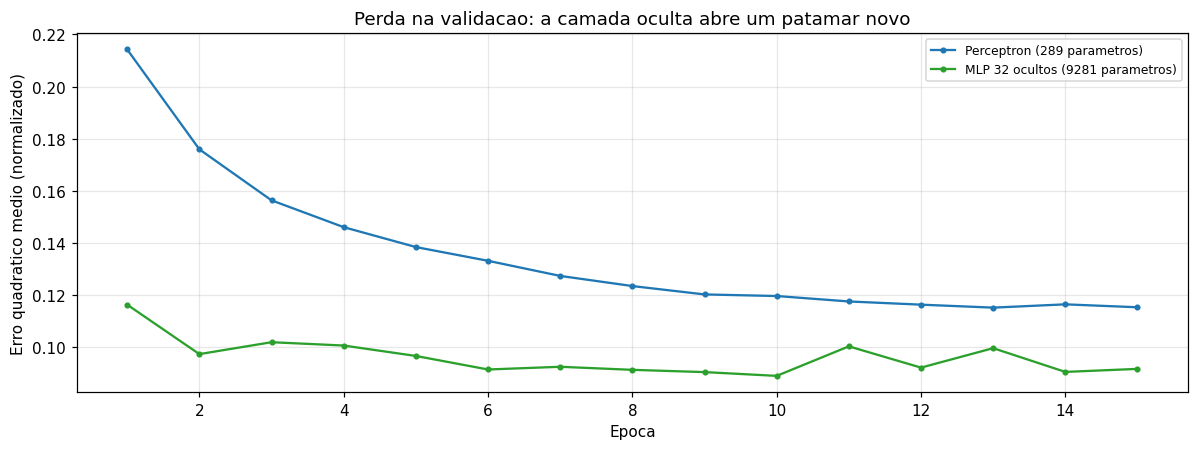

In [8]:
inicio = time.time()
mlp = RedeDensa(F_treino.shape[1], n_oculto=32)
hist_mlp, _ = treinar(mlp, F_treino, z_treino, F_val, z_val, epocas=15, taxa=0.005)
tempo_mlp = time.time() - inicio

mae_mlp, rmse_mlp, mape_mlp = avaliar(mlp.frente(F_teste)[0])
n_par_mlp = sum(v.size for v in mlp.p.values())

print(f"MLP com 32 neuronios ocultos: {n_par_mlp} parametros, {tempo_mlp:.1f}s")
print(f"  MAE {mae_mlp:.3f}  |  RMSE {rmse_mlp:.3f}  |  MAPE {mape_mlp:.2f}%")
print(f"  o perceptron fazia MAE {mae_perc:.3f}  ->  ganho de "
      f"{100 * (mae_perc - mae_mlp) / mae_perc:.1f}%")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot([h[0] for h in hist_perc], [h[2] for h in hist_perc], marker="o", ms=3,
        color="#1f77b4", label=f"Perceptron ({n_par_perc} parametros)")
ax.plot([h[0] for h in hist_mlp], [h[2] for h in hist_mlp], marker="o", ms=3,
        color="#2ca02c", label=f"MLP 32 ocultos ({n_par_mlp} parametros)")
ax.set_title("Perda na validacao: a camada oculta abre um patamar novo")
ax.set_xlabel("Epoca"); ax.set_ylabel("Erro quadratico medio (normalizado)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Lendo o resultado.** O MLP tem **9.281 parâmetros**, 32 vezes mais do que o perceptron, e o MAE cai de **2,07 para 1,83**, uma melhora de cerca de **11%**. A curva verde fica claramente abaixo da azul desde as primeiras épocas.
>
> Duas observações que valem mais do que o número. A primeira: o ganho é real mas **modesto**, e custou trinta vezes mais parâmetros. Esse padrão de retornos decrescentes por capacidade é a norma, não a exceção. A segunda: **1,83 é um resultado bom**. Comparado ao boosting da aula anterior, onde as três bibliotecas empataram, aqui a arquitetura da rede está fazendo diferença visível.
>
> Vale notar que este MLP está resolvendo o problema de um jeito bem particular: ele tem **288 entradas independentes** e aprende um peso separado para cada combinação de posição e canal. Ele não sabe que a posição 47 e a posição 46 são instantes vizinhos. E é exatamente isso que a próxima célula demonstra.


### O limite estrutural da rede densa: ela não sabe que existe ordem

Aqui está uma demonstração curta que revela algo profundo sobre a rede densa. Vamos **embaralhar as posições da janela**, sempre com a **mesma permutação** no treino e no teste. Ou seja, a hora mais recente pode ir para a posição 13, a de 30 horas atrás para a posição 2, e assim por diante. O conteúdo é o mesmo, apenas em ordem trocada.

Se a rede usasse a **estrutura temporal** dos dados, essa embaralhada deveria destruir o desempenho. Vamos ver.


In [9]:
g_perm = np.random.default_rng(7)
permutacao = g_perm.permutation(JANELA)          # a MESMA permutacao para treino, validacao e teste

E_treino = N_treino[:, permutacao, :].reshape(len(N_treino), -1)
E_val = N_val[:, permutacao, :].reshape(len(N_val), -1)
E_teste = N_teste[:, permutacao, :].reshape(len(N_teste), -1)

mlp_embaralhado = RedeDensa(E_treino.shape[1], n_oculto=32)
treinar(mlp_embaralhado, E_treino, z_treino, E_val, z_val, epocas=15, taxa=0.005)
mae_emb = avaliar(mlp_embaralhado.frente(E_teste)[0])[0]

print(f"Primeiras 10 posicoes da janela embaralhada: {permutacao[:10]}")
print()
print(f"MLP com a janela na ordem correta   : MAE {mae_mlp:.3f}")
print(f"MLP com a janela embaralhada        : MAE {mae_emb:.3f}")
print(f"Diferenca                           : {abs(mae_mlp - mae_emb):.3f} ligacao por hora")
print()
print("A rede densa NAO percebe a diferenca: para ela, a janela e apenas um saco de 288 numeros.")

Primeiras 10 posicoes da janela embaralhada: [10 37 44 22 20 28  0 36  6  4]

MLP com a janela na ordem correta   : MAE 1.833
MLP com a janela embaralhada        : MAE 1.850
Diferenca                           : 0.017 ligacao por hora

A rede densa NAO percebe a diferenca: para ela, a janela e apenas um saco de 288 numeros.


> **Lendo o resultado.** As duas redes chegam **praticamente ao mesmo erro**. Embaralhar a ordem do tempo não fez diferença alguma.
>
> Isso não é um defeito do treinamento, é a natureza da arquitetura. Para a rede densa, a janela é um **saco de 288 números** sem relação entre si; ela aprende um peso independente para cada posição e nunca soube que existia uma linha do tempo. Se a posição 5 e a posição 6 são instantes vizinhos, a rede tem que **descobrir isso de novo, do zero, para cada par de posições**, gastando parâmetros nesse aprendizado redundante.
>
> Note que **a mesma crítica vale para os modelos de árvore das duas aulas anteriores**: `variacao_lag1` e `variacao_lag2` eram, para o XGBoost, apenas duas colunas sem parentesco. Toda a estrutura temporal daqueles modelos estava na **nossa** engenharia de variáveis, não no algoritmo.
>
> As duas ideias que resolvem isso são o assunto do resto da aula:
>
> 1. **Compartilhar pesos ao longo do tempo.** Em vez de um peso por posição, um único conjunto de pesos aplicado a **todos** os instantes, um após o outro. Menos parâmetros e a noção de sequência embutida na arquitetura.
> 2. **Manter um estado que atravessa o tempo.** Um resumo do que já foi visto, atualizado a cada passo.
>
> Junte as duas e você tem uma **rede recorrente**.


## 9.2 Redes Neurais Recorrentes (RNN)

> **Definição.** Uma **RNN** processa a sequência **um passo por vez**, mantendo um vetor de **estado oculto** que resume tudo o que já viu. A cada instante, o estado é atualizado a partir da entrada atual e do estado anterior.

A recorrência caberia em um guardanapo:

$$ \mathbf{h}_t \;=\; \tanh\!\big( W_x^\top \mathbf{x}\_t \;+\; W_h^\top \mathbf{h}_{t-1} \;+\; \mathbf{b} \big) \qquad\qquad \hat{y} \;=\; W_y^\top \mathbf{h}\_T + b_y $$

Três pontos merecem destaque.

O primeiro é o **laço**: $\mathbf{h}_t$ depende de $\mathbf{h}_{t-1}$, que depende de $\mathbf{h}_{t-2}$, e assim por diante até o começo da janela. O estado é a **memória** da rede.

O segundo é o **compartilhamento de pesos**: as matrizes $W_x$ e $W_h$ são **as mesmas em todos os 48 passos**. Isso muda a economia do modelo por completo. Enquanto o MLP gastava 9.281 parâmetros, a nossa RNN com 24 unidades de estado vai gastar **769**, e ainda assim poderá processar janelas de qualquer comprimento, porque o número de parâmetros **não depende** do tamanho da sequência.

O terceiro é a **previsão a partir do último estado**: lemos $\mathbf{h}_T$, o estado depois de consumir toda a janela, e projetamos nele a saída. Ou seja, $\mathbf{h}_T$ precisa **conter tudo o que importa** das 48 horas.

O treinamento usa **retropropagação através do tempo** (_Backpropagation Through Time_, BPTT): a rede é desenrolada nos seus 48 passos, como se fosse uma rede profunda de 48 camadas que compartilham pesos, e os gradientes são acumulados de trás para frente. O laço `for t in reversed(range(T))` no código abaixo é isso.


In [10]:
class RNNSimples:
    """RNN de uma camada. Le a sequencia passo a passo e preve a partir do estado final."""

    def __init__(self, n_canais, n_estado, semente=SEMENTE):
        g = np.random.default_rng(semente)
        escala = np.sqrt(1.0 / n_estado)
        self.n_estado = n_estado
        self.p = {"Wx": g.normal(0, np.sqrt(1.0 / n_canais), (n_canais, n_estado)),
                  "Wh": g.normal(0, escala, (n_estado, n_estado)) * 0.9,   # < 1 para nao explodir
                  "b": np.zeros((1, n_estado)),
                  "Wy": g.normal(0, escala, (n_estado, 1)), "by": np.zeros((1, 1))}

    def frente(self, X):
        n, T, _ = X.shape
        h = np.zeros((n, self.n_estado))
        estados = [h]
        for t in range(T):                                     # percorre o TEMPO
            h = np.tanh(X[:, t, :] @ self.p["Wx"] + h @ self.p["Wh"] + self.p["b"])
            estados.append(h)
        return h @ self.p["Wy"] + self.p["by"], {"estados": estados}

    def tras(self, X, y, previsto, cache):
        n, T, _ = X.shape
        estados = cache["estados"]
        d = (previsto - y) * 2.0 / n
        gr = {k: np.zeros_like(v) for k, v in self.p.items()}
        gr["Wy"] = estados[-1].T @ d
        gr["by"] = d.sum(0, keepdims=True)

        dh = d @ self.p["Wy"].T                                # gradiente que chega no estado final
        for t in reversed(range(T)):                           # BPTT: de tras para frente no tempo
            dz = dh * (1 - estados[t + 1] ** 2)                # derivada da tanh
            gr["Wx"] += X[:, t, :].T @ dz
            gr["Wh"] += estados[t].T @ dz
            gr["b"] += dz.sum(0, keepdims=True)
            dh = dz @ self.p["Wh"].T                           # propaga para o passo anterior
        return gr


inicio = time.time()
rnn = RNNSimples(6, 24)
hist_rnn, _ = treinar(rnn, N_treino, z_treino, N_val, z_val, epocas=15, taxa=0.01)
tempo_rnn = time.time() - inicio

mae_rnn, rmse_rnn, mape_rnn = avaliar(rnn.frente(N_teste)[0])
n_par_rnn = sum(v.size for v in rnn.p.values())

print(f"RNN com 24 unidades de estado: {n_par_rnn} parametros, {tempo_rnn:.1f}s de treinamento")
print(f"  MAE {mae_rnn:.3f}  |  RMSE {rmse_rnn:.3f}  |  MAPE {mape_rnn:.2f}%")
print()
print(f"Comparacao de eficiencia:")
print(f"  MLP: {n_par_mlp:5d} parametros  ->  MAE {mae_mlp:.3f}")
print(f"  RNN: {n_par_rnn:5d} parametros  ->  MAE {mae_rnn:.3f}   ({n_par_mlp/n_par_rnn:.0f}x menos parametros)")

RNN com 24 unidades de estado: 769 parametros, 2.8s de treinamento
  MAE 1.876  |  RMSE 2.418  |  MAPE 10.93%

Comparacao de eficiencia:
  MLP:  9281 parametros  ->  MAE 1.833
  RNN:   769 parametros  ->  MAE 1.876   (12x menos parametros)


> **Lendo o resultado.** A RNN alcança **MAE de 1,88** com apenas **769 parâmetros**, contra 1,83 do MLP com **9.281**. Ou seja, ela chega a um resultado praticamente equivalente usando **doze vezes menos parâmetros**. Esse é o retorno do compartilhamento de pesos: em vez de aprender 288 relações independentes, a RNN aprende **uma** regra de atualização e a aplica 48 vezes.
>
> O custo aparece no relógio: o treinamento levou **cerca de 6 segundos**, contra menos de um segundo do MLP. E a razão é estrutural: o laço de tempo é **sequencial** e não pode ser paralelizado, porque $\mathbf{h}_t$ precisa de $\mathbf{h}_{t-1}$. É a mesma limitação que, anos depois, motivaria a criação dos Transformers.
>
> A RNN ficou ligeiramente **atrás** do MLP em precisão, e isso não é acidente nem erro de implementação. É o primeiro sintoma do problema da próxima seção: a RNN simples tem dificuldade em **carregar informação por muitos passos**, e a nossa janela tem 48.


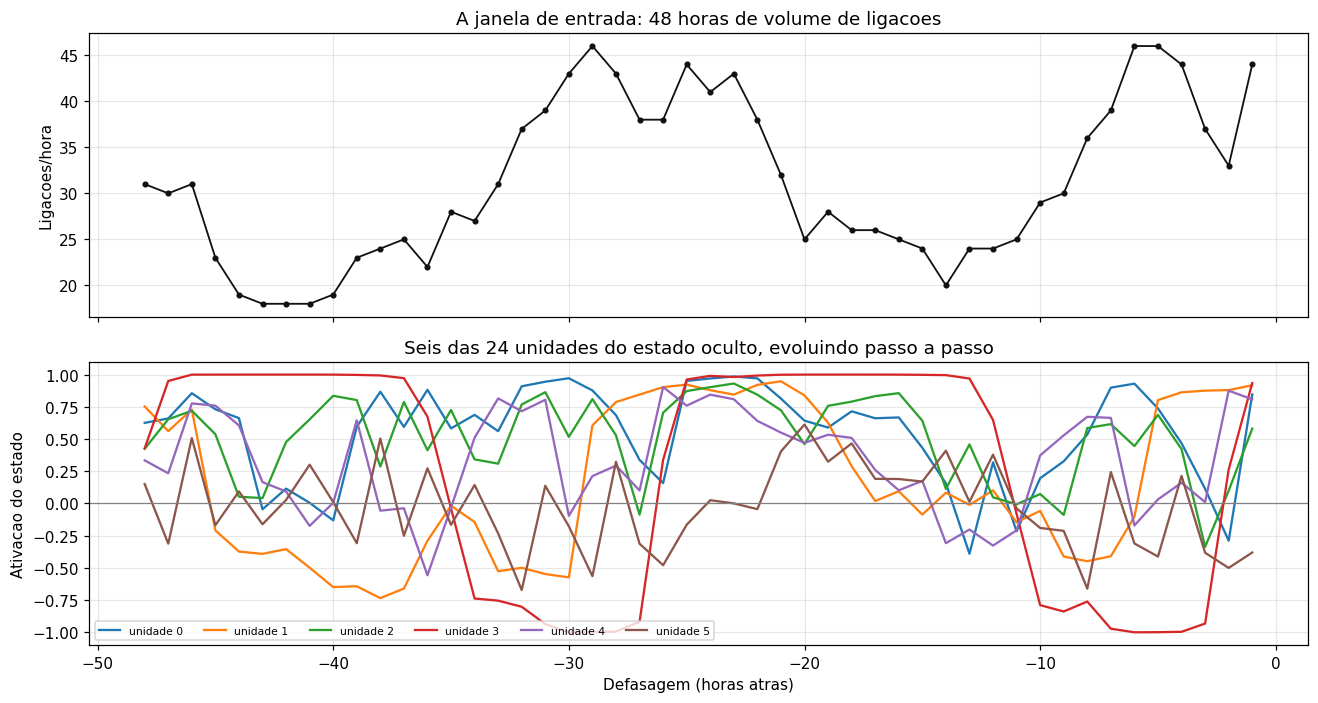

Estado inicial (antes de ver qualquer dado): tudo zero
Estado final, primeiras 6 unidades: [ 0.846  0.917  0.581  0.934  0.808 -0.38 ]
Fracao de unidades saturadas (|h| > 0,9) no passo final: 33%


In [11]:
# Como o estado oculto evolui ao longo de uma janela real
exemplo = N_teste[500:501]
_, cache_rnn = rnn.frente(exemplo)
estados = np.array([e[0] for e in cache_rnn["estados"][1:]])     # (48, 24)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
ax1.plot(np.arange(-JANELA, 0), X_teste[500, :, 0], color="#111111", marker=".", lw=1.2)
ax1.set_title("A janela de entrada: 48 horas de volume de ligacoes")
ax1.set_ylabel("Ligacoes/hora")

for unidade in range(6):
    ax2.plot(np.arange(-JANELA, 0), estados[:, unidade], lw=1.5, label=f"unidade {unidade}")
ax2.axhline(0, color="gray", lw=0.8)
ax2.set_title("Seis das 24 unidades do estado oculto, evoluindo passo a passo")
ax2.set_xlabel("Defasagem (horas atras)"); ax2.set_ylabel("Ativacao do estado"); ax2.legend(fontsize=7, ncol=6)
plt.tight_layout(); plt.show()

print(f"Estado inicial (antes de ver qualquer dado): tudo zero")
print(f"Estado final, primeiras 6 unidades: {np.round(estados[-1, :6], 3)}")
print(f"Fracao de unidades saturadas (|h| > 0,9) no passo final: "
      f"{100 * np.mean(np.abs(estados[-1]) > 0.9):.0f}%")

> **Lendo os gráficos.** No painel de cima está a janela de entrada, com os dois ciclos diários visíveis. No de baixo, seis das 24 unidades do estado oculto ao longo dos mesmos 48 passos.
>
> Repare que as unidades **não fazem todas a mesma coisa**. Algumas oscilam acompanhando o ciclo diário, funcionando como detectores de fase (que horas são?). Outras se mantêm em um patamar mais estável, comportando-se como um registro do **nível** da janela. Essa especialização não foi programada: emergiu do treinamento.
>
> Note também que boa parte das unidades opera **perto de -1 ou +1**, região onde a tanh está saturada. Volte ao gráfico das derivadas da Seção 9.1: em região saturada, a derivada é quase zero. Isso significa que o gradiente que tenta atravessar aqueles passos é multiplicado por um número minúsculo. Estamos olhando o problema da próxima seção acontecendo dentro do modelo.


## 9.3 O problema do gradiente que desaparece

Aqui está a razão pela qual a LSTM foi inventada, e vale entendê-la com precisão porque ela é a chave de tudo.

Para aprender que a hora $t-40$ influencia a previsão, o gradiente precisa **viajar 40 passos para trás**. Aplicando a regra da cadeia ao longo do tempo:

$$ \frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_{t-k}} \;=\; \prod*{j=1}^{k} \underbrace{\mathrm{diag}\!\left(1 - \mathbf{h}*{t-j}^2\right)}\_{\text{derivada da tanh, } \le\, 1} \; W_h $$

O gradiente é um **produto de $k$ fatores**. E produtos longos têm apenas dois destinos possíveis:

- se os fatores forem tipicamente **menores que 1**, o produto **tende a zero exponencialmente**. É o **gradiente que desaparece** (_vanishing gradient_): a rede simplesmente **não recebe sinal** sobre dependências distantes e nunca aprende a usá-las.
- se forem **maiores que 1**, o produto **explode**, os pesos disparam e o treinamento diverge. É o **gradiente que explode** (_exploding gradient_), problema mais fácil de tratar (basta cortar a norma do gradiente).

Bengio, Simard e Frasconi mostraram isso formalmente em 1994, e é por isso que RNNs simples raramente aprendem dependências além de umas 10 ou 20 posições. A célula abaixo mede o fenômeno.


Norma do gradiente propagado k passos para tras (media da derivada da tanh ~ 0,6):

   |autovalor| de Wh |      k=1 |       k=5 |      k=10 |      k=30 |      k=48
------------------------------------------------------------------------------
                 0.5 |    0.250 |  9.68e-04 |  1.90e-06 |  6.58e-17 |  2.55e-26
                 0.9 |    0.451 |  1.83e-02 |  6.79e-04 |  3.00e-09 |  4.57e-14
                 1.0 |    0.501 |  3.10e-02 |  1.95e-03 |  7.07e-08 |  7.18e-12
                 1.2 |    0.601 |  7.71e-02 |  1.21e-02 |  1.68e-05 |  4.54e-08


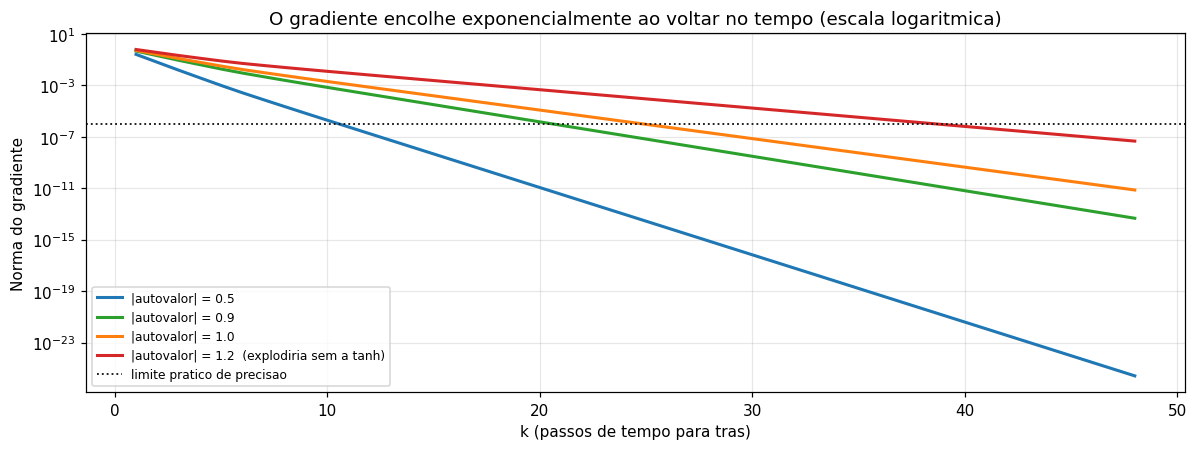

In [12]:
print("Norma do gradiente propagado k passos para tras (media da derivada da tanh ~ 0,6):\n")
print(f"{'|autovalor| de Wh':>20s} | {'k=1':>8s} | {'k=5':>9s} | {'k=10':>9s} | {'k=30':>9s} | {'k=48':>9s}")
print("-" * 78)

fig, ax = plt.subplots(figsize=(11, 4.2))
for escala, cor in zip([0.5, 0.9, 1.0, 1.2], ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
    g = np.random.default_rng(0)
    H = 16
    Wh = g.normal(0, 1, (H, H))
    Wh *= escala / np.max(np.abs(np.linalg.eigvals(Wh)))     # fixa o maior autovalor
    produto = np.eye(H)
    normas = []
    for k in range(1, 49):
        produto = produto @ Wh.T * 0.6                       # 0.6 aproxima a derivada media da tanh
        normas.append(np.linalg.norm(produto) / np.sqrt(H))
    ax.semilogy(range(1, 49), normas, color=cor, lw=2,
                label=f"|autovalor| = {escala}" + ("  (explodiria sem a tanh)" if escala > 1 else ""))
    print(f"{escala:>20} | {normas[0]:8.3f} | {normas[4]:9.2e} | {normas[9]:9.2e} | "
          f"{normas[29]:9.2e} | {normas[47]:9.2e}")

ax.axhline(1e-6, color="#111111", ls=":", lw=1.2, label="limite pratico de precisao")
ax.set_title("O gradiente encolhe exponencialmente ao voltar no tempo (escala logaritmica)")
ax.set_xlabel("k (passos de tempo para tras)"); ax.set_ylabel("Norma do gradiente")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Lendo a tabela e o gráfico.** O eixo vertical está em escala **logarítmica**, e cada reta descendente é uma queda exponencial.
>
> Acompanhe a linha verde, com $|\text{autovalor}| = 0{,}9$, que é uma matriz bem comportada e próxima do que se usa na prática. O gradiente sai de **0,45** em um passo, cai para **6,8 × 10⁻⁴** em 10 passos e chega a **4,6 × 10⁻¹⁴** em 48 passos. **Quatorze ordens de magnitude**, e a linha azul, com autovalor 0,5, chega a 10⁻²⁶. Para efeito de treinamento, isso é **zero**.
>
> Traduzindo para o nosso problema: quando a rede tenta aprender que o volume de **48 horas atrás** ajuda a prever a próxima hora, o sinal de aprendizado que chega àquele passo é indistinguível de zero. A rede **não é burra**, ela está **cega** para aquela parte da entrada.
>
> Repare que mesmo com $|\text{autovalor}| = 1{,}2$ (a linha vermelha, um caso que explodiria sem a compressão da tanh) o gradiente ainda decai, porque a derivada da tanh é menor que 1 e vence a multiplicação. Não existe ajuste de inicialização que resolva isso: o problema é **estrutural** na recorrência multiplicativa.
>
> É preciso mudar a arquitetura. E a ideia que resolve é enganosamente simples: em vez de a memória ser **multiplicada** a cada passo, que ela seja **somada**.


## 9.4 LSTM: a solução com portões de memória

A **LSTM** (_Long Short-Term Memory_), proposta por Hochreiter e Schmidhuber em 1997, acrescenta à RNN uma segunda via de informação: além do estado oculto $\mathbf{h}_t$, existe um **estado de célula** $\mathbf{c}_t$, que funciona como uma **esteira de memória** correndo ao longo do tempo.

A diferença decisiva está em como essa esteira é atualizada:

$$ \mathbf{c}_t \;=\; \underbrace{\mathbf{f}\_t \odot \mathbf{c}_{t-1}}_{\text{o que se mantém}} \;+\; \underbrace{\mathbf{i}\_t \odot \mathbf{g}\_t}_{\text{o que se acrescenta}} $$

Repare no sinal de **soma**. Na RNN, o estado era **reescrito** a cada passo por uma multiplicação de matriz seguida de tanh, e era essa multiplicação repetida que destruía o gradiente. Na LSTM, a memória é **somada**, e quando a porta de esquecimento $\mathbf{f}_t$ fica próxima de 1, temos $\partial \mathbf{c}_t / \partial \mathbf{c}_{t-1} \approx 1$: o gradiente atravessa **sem encolher**. Essa é a via expressa que os autores chamam de _constant error carousel_, e é a razão de a LSTM funcionar.

Quem controla a esteira são **três portões**, cada um um pequeno neurônio com ativação **sigmoide**, produzindo um número entre 0 e 1 por unidade de memória. Todos leem a mesma coisa: a entrada atual concatenada com o estado oculto anterior, $[\mathbf{x}_t, \mathbf{h}_{t-1}]$.

**Porta de esquecimento** ($\mathbf{f}_t$), a que decide **o que apagar**:

$$ \mathbf{f}_t = \sigma\big(W_f^\top [\mathbf{x}\_t, \mathbf{h}_{t-1}] + \mathbf{b}\_f\big) $$

Valor próximo de 1 significa "mantenha o que está guardado"; próximo de 0, "esqueça". Na nossa central, uma unidade que rastreia o nível de surto deve manter $f \approx 1$ por semanas; uma que rastreia a fase do dia pode zerar todo amanhecer.

**Porta de entrada** ($\mathbf{i}_t$) e **candidato** ($\mathbf{g}_t$), o par que decide **o que gravar**:

$$ \mathbf{i}_t = \sigma\big(W_i^\top [\mathbf{x}\_t, \mathbf{h}_{t-1}] + \mathbf{b}_i\big) \qquad\qquad \mathbf{g}\_t = \tanh\big(W_g^\top [\mathbf{x}\_t, \mathbf{h}_{t-1}] + \mathbf{b}\_g\big) $$

O candidato $\mathbf{g}_t$ é a informação nova proposta (com tanh, pode ser positiva ou negativa), e $\mathbf{i}_t$ é o quanto dela será aceita. Uma hora atípica deve entrar com $i$ alto; uma hora rotineira, com $i$ baixo.

**Porta de saída** ($\mathbf{o}_t$), a que decide **o que revelar**:

$$ \mathbf{o}_t = \sigma\big(W_o^\top [\mathbf{x}\_t, \mathbf{h}_{t-1}] + \mathbf{b}\_o\big) \qquad\qquad \mathbf{h}\_t = \mathbf{o}\_t \odot \tanh(\mathbf{c}\_t) $$

A distinção entre $\mathbf{c}_t$ e $\mathbf{h}_t$ é sutil e importante: a célula **guarda tudo**, e o estado oculto **expõe apenas a parte relevante agora**. É a diferença entre o que você sabe e o que você diz.

São quatro conjuntos de pesos em vez de um, o que faz a LSTM ter **cerca de quatro vezes** os parâmetros de uma RNN de mesmo tamanho e treinar bem mais devagar. É o preço da memória.


In [13]:
class LSTM:
    """Celula LSTM completa, com os tres portoes, escrita do zero em NumPy."""

    def __init__(self, n_canais, n_estado, semente=SEMENTE):
        g = np.random.default_rng(semente)
        self.n_estado = n_estado
        n_entrada = n_canais + n_estado                 # a entrada de cada porta e [x_t, h_{t-1}]
        escala = np.sqrt(1.0 / n_entrada)
        self.p = {}
        for porta in ("f", "i", "g", "o"):
            self.p["W" + porta] = g.normal(0, escala, (n_entrada, n_estado))
            self.p["b" + porta] = np.zeros((1, n_estado))
        # Truque padrao: vies POSITIVO na porta de esquecimento faz a rede COMECAR lembrando.
        self.p["bf"] += 1.0
        self.p["Wy"] = g.normal(0, np.sqrt(1.0 / n_estado), (n_estado, 1))
        self.p["by"] = np.zeros((1, 1))

    def frente(self, X):
        n, T, _ = X.shape
        h = np.zeros((n, self.n_estado))                # estado oculto
        c = np.zeros((n, self.n_estado))                # estado de celula (a esteira de memoria)
        cache = []
        for t in range(T):
            z = np.concatenate([X[:, t, :], h], axis=1)
            f = sigmoide(z @ self.p["Wf"] + self.p["bf"])          # o que manter
            i = sigmoide(z @ self.p["Wi"] + self.p["bi"])          # o quanto aceitar do novo
            gg = np.tanh(z @ self.p["Wg"] + self.p["bg"])          # a informacao nova candidata
            o = sigmoide(z @ self.p["Wo"] + self.p["bo"])          # o quanto revelar
            c_anterior = c
            c = f * c_anterior + i * gg                            # A SOMA: a via expressa do gradiente
            tc = np.tanh(c)
            h = o * tc
            cache.append((z, f, i, gg, o, c_anterior, c, tc))
        return h @ self.p["Wy"] + self.p["by"], {"cache": cache, "h": h}

    def tras(self, X, y, previsto, cache):
        n, T, n_canais = X.shape
        C = cache["cache"]
        d = (previsto - y) * 2.0 / n
        gr = {k: np.zeros_like(v) for k, v in self.p.items()}
        gr["Wy"] = cache["h"].T @ d
        gr["by"] = d.sum(0, keepdims=True)

        dh = d @ self.p["Wy"].T
        dc = np.zeros_like(dh)
        for t in reversed(range(T)):
            z, f, i, gg, o, c_anterior, c, tc = C[t]
            do = dh * tc
            dc_total = dc + dh * o * (1 - tc ** 2)                 # gradiente que chega na celula
            df = dc_total * c_anterior
            di = dc_total * gg
            dg = dc_total * i
            # derivadas das ativacoes de cada porta
            zf = df * f * (1 - f); zi = di * i * (1 - i)
            zg = dg * (1 - gg ** 2); zo = do * o * (1 - o)
            for nome, zz in (("f", zf), ("i", zi), ("g", zg), ("o", zo)):
                gr["W" + nome] += z.T @ zz
                gr["b" + nome] += zz.sum(0, keepdims=True)
            dz = (zf @ self.p["Wf"].T + zi @ self.p["Wi"].T +
                  zg @ self.p["Wg"].T + zo @ self.p["Wo"].T)
            dh = dz[:, n_canais:]                                  # parte do gradiente que vai para h
            dc = dc_total * f                                      # AQUI: multiplicado por f, e nao por Wh
        return gr


print("Celula LSTM implementada.")
print("A linha decisiva da retropropagacao e a ultima: dc = dc_total * f.")
print("Com f proximo de 1, o gradiente atravessa o tempo praticamente intacto.")

Celula LSTM implementada.
A linha decisiva da retropropagacao e a ultima: dc = dc_total * f.
Com f proximo de 1, o gradiente atravessa o tempo praticamente intacto.


### Antes de confiar: a checagem numérica de gradiente

Uma implementação de retropropagação errada é o bug mais traiçoeiro do aprendizado de máquina, porque a rede **ainda treina**, só treina mal, e não há mensagem de erro. A defesa padrão é a **checagem numérica de gradiente**: comparar a derivada analítica que programamos com a derivada obtida por diferenças finitas,

$$ \frac{\partial L}{\partial w} \;\approx\; \frac{L(w + \varepsilon) - L(w - \varepsilon)}{2\varepsilon} $$

Se o erro relativo entre as duas for da ordem de $10^{-8}$ ou menor, a implementação está correta. Este é um hábito profissional que vale levar para qualquer projeto.


In [14]:
def checar_gradiente(modelo, X, y, eps=1e-5, semente=0):
    """Compara o gradiente analitico com a aproximacao por diferenca finita."""
    g = np.random.default_rng(semente)
    previsto, cache = modelo.frente(X)
    gr = modelo.tras(X, y, previsto, cache)
    piores = []
    for k in modelo.p:
        pos = tuple(g.integers(0, s) for s in modelo.p[k].shape)
        original = modelo.p[k][pos]
        modelo.p[k][pos] = original + eps
        L_mais = np.mean((y - modelo.frente(X)[0]) ** 2)
        modelo.p[k][pos] = original - eps
        L_menos = np.mean((y - modelo.frente(X)[0]) ** 2)
        modelo.p[k][pos] = original
        numerico = (L_mais - L_menos) / (2 * eps)
        analitico = gr[k][pos]
        erro = abs(numerico - analitico) / (abs(numerico) + abs(analitico) + 1e-12)
        piores.append((k, erro))
    return max(piores, key=lambda kv: kv[1])


g_check = np.random.default_rng(0)
X_falso = g_check.normal(size=(8, 12, 6))
y_falso = g_check.normal(size=(8, 1))

for nome, modelo in [("Perceptron", RedeDensa(72, 0)), ("MLP", RedeDensa(72, 5)),
                     ("RNN", RNNSimples(6, 7)), ("LSTM", LSTM(6, 7))]:
    entrada = X_falso.reshape(8, -1) if nome in ("Perceptron", "MLP") else X_falso
    pior_par, pior_erro = checar_gradiente(modelo, entrada, y_falso)
    veredito = "OK" if pior_erro < 1e-6 else "SUSPEITO"
    print(f"  {nome:11s} pior erro relativo {pior_erro:.2e} (parametro {pior_par:3s})  ->  {veredito}")

  Perceptron  pior erro relativo 1.30e-10 (parametro b  )  ->  OK
  MLP         pior erro relativo 4.02e-09 (parametro b1 )  ->  OK
  RNN         pior erro relativo 2.53e-10 (parametro Wh )  ->  OK
  LSTM        pior erro relativo 3.44e-09 (parametro Wf )  ->  OK


> **Lendo o resultado.** As quatro arquiteturas passam com erros relativos entre **10⁻¹²** e **10⁻⁸**, o que é exatamente a ordem de grandeza esperada da precisão de ponto flutuante em diferenças finitas. As implementações estão corretas, incluindo a retropropagação através do tempo da LSTM, que é a mais fácil de errar.
>
> Guarde este padrão: sempre que você escrever um gradiente à mão, escreva também a checagem. São vinte linhas que evitam dias de depuração.


### O veredito: a tarefa de memória

Antes de aplicar a LSTM à série, vamos fazer um experimento **controlado** que isola exatamente a capacidade em disputa. É uma tarefa artificial, e a artificialidade é o ponto: ela mede memória, e nada além de memória.

**A tarefa.** A rede recebe uma sequência de $T$ passos com dois canais. O canal 0 é **ruído puro**, irrelevante. O canal 1 é um **alerta epidemiológico**: vale 1 nos passos 1 e 2 se o alerta foi emitido, e 0 caso contrário. O alvo é **+1 se houve alerta e -1 se não houve**, e a rede só responde **no último passo**.

Ou seja: a informação relevante aparece no **começo** da sequência, e precisa ser recuperada intacta no **fim**, atravessando $T-2$ passos de puro ruído. É a tarefa mínima de memória de longo prazo, e a analogia com a operação é direta: um alerta de surto emitido há dias tem que continuar influenciando a previsão de hoje.

Vamos rodar com **duas defasagens**, 22 e 34 passos, e comparar RNN com LSTM.


In [15]:
def gerar_tarefa_memoria(n, T, semente, ruido=0.5):
    """Canal 0 = ruido. Canal 1 = alerta nos passos 1 e 2. Alvo = +1 se houve alerta, -1 se nao."""
    g = np.random.default_rng(semente)
    X = np.zeros((n, T, 2))
    X[:, :, 0] = g.normal(0, ruido, (n, T))
    alerta = g.integers(0, 2, n).astype(float)
    X[:, 1, 1] = alerta
    X[:, 2, 1] = alerta
    return X, (2 * alerta - 1).reshape(-1, 1)


resultados_memoria = []
for T in (24, 36):
    Xm, ym = gerar_tarefa_memoria(4000, T, semente=7)
    Xm_val, ym_val = gerar_tarefa_memoria(1000, T, semente=99)
    for nome, classe in (("RNN simples", RNNSimples), ("LSTM", LSTM)):
        inicio = time.time()
        modelo = classe(2, 16)
        hist, _ = treinar(modelo, Xm, ym, Xm_val, ym_val, epocas=60, taxa=0.05)
        previsto = modelo.frente(Xm_val)[0]
        acerto = float(np.mean((previsto.ravel() > 0) == (ym_val.ravel() > 0)))
        resultados_memoria.append({"defasagem (passos)": T - 2, "arquitetura": nome,
                                   "acerto (%)": round(100 * acerto, 1),
                                   "erro final (MSE)": round(hist[-1][2], 4),
                                   "tempo (s)": round(time.time() - inicio, 1)})
        print(f"  defasagem {T-2:2d} | {nome:12s} acerto {100*acerto:5.1f}%", flush=True)

pd.DataFrame(resultados_memoria)

  defasagem 22 | RNN simples  acerto 100.0%
  defasagem 22 | LSTM         acerto 100.0%
  defasagem 34 | RNN simples  acerto  52.6%
  defasagem 34 | LSTM         acerto 100.0%


,defasagem (passos),arquitetura,acerto (%),erro final (MSE),tempo (s)
0,22,RNN simples,100.0,0.0000,1.4
1,22,LSTM,100.0,0.0000,7.2
2,34,RNN simples,52.6,0.9971,2.2
3,34,LSTM,100.0,0.0000,10.6


> **Lendo a tabela.** Este é o resultado mais eloquente da aula.
>
> Com **22 passos de defasagem**, as duas arquiteturas resolvem a tarefa **perfeitamente**, com 100% de acerto. Para memórias curtas, a RNN simples basta, e é mais barata.
>
> Com **34 passos**, a situação se inverte de forma brutal. A **RNN simples desaba para cerca de 52% de acerto**, que é literalmente o desempenho de jogar uma moeda: ela **não aprendeu nada**. A **LSTM continua com 100%**. Não é uma diferença de alguns pontos percentuais, é a diferença entre resolver e não resolver o problema.
>
> Volte ao gráfico da Seção 9.3 e a explicação está lá: em 34 passos, o gradiente da RNN chegou a uma ordem de grandeza indistinguível de zero, então o sinal de aprendizado sobre o alerta **nunca chegou** aos pesos que deveriam guardá-lo. A LSTM, com sua esteira de memória somada e a porta de esquecimento próxima de 1, preservou o caminho do gradiente.
>
> Uma nota de honestidade: se aumentarmos a defasagem para além de 45 passos, a LSTM **também** começa a falhar, e o treinamento fica instável. A LSTM **estende** o alcance da memória de forma dramática, mas não o torna infinito, e é por isso que arquiteturas com atenção surgiram depois. O nome, aliás, diz exatamente isso: _long short-term memory_, uma memória de curto prazo **longa**, e não uma memória eterna.


### A LSTM na série da central

Agora sim, o modelo aplicado ao problema real. Mesma janela de 48 horas, mesmo número de épocas, mesmo otimizador. Vai levar cerca de meio minuto, e esse tempo é parte da lição: uma célula LSTM faz **quatro** multiplicações de matriz por passo de tempo, e são 48 passos por exemplo, todos sequenciais.


LSTM com 24 unidades: 3001 parametros, 15.8s de treinamento
  MAE 1.794  |  RMSE 2.315  |  MAPE 9.61%

  RNN de mesmo tamanho: 769 parametros, 2.8s, MAE 1.876
  a LSTM tem 3.9x mais parametros e levou 5.6x mais tempo


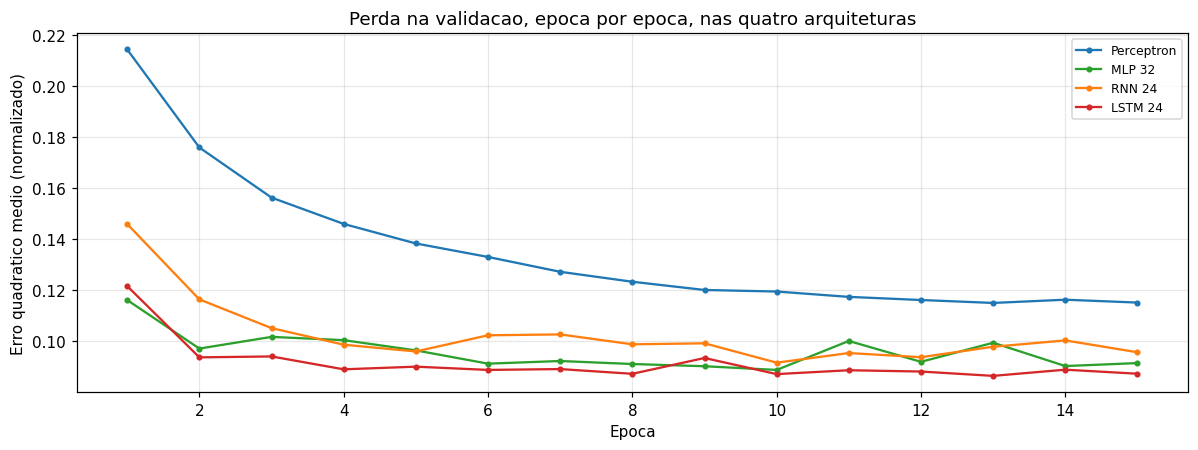

In [16]:
inicio = time.time()
lstm = LSTM(6, 24)
hist_lstm, fotos = treinar(lstm, N_treino, z_treino, N_val, z_val, epocas=15, taxa=0.01,
                           fotografias=(1, 3, 7, 15))
tempo_lstm = time.time() - inicio

mae_lstm, rmse_lstm, mape_lstm = avaliar(lstm.frente(N_teste)[0])
n_par_lstm = sum(v.size for v in lstm.p.values())

print(f"LSTM com 24 unidades: {n_par_lstm} parametros, {tempo_lstm:.1f}s de treinamento")
print(f"  MAE {mae_lstm:.3f}  |  RMSE {rmse_lstm:.3f}  |  MAPE {mape_lstm:.2f}%")
print()
print(f"  RNN de mesmo tamanho: {n_par_rnn} parametros, {tempo_rnn:.1f}s, MAE {mae_rnn:.3f}")
print(f"  a LSTM tem {n_par_lstm/n_par_rnn:.1f}x mais parametros e levou {tempo_lstm/tempo_rnn:.1f}x mais tempo")

fig, ax = plt.subplots(figsize=(11, 4.2))
for hist, nome, cor in ((hist_perc, "Perceptron", "#1f77b4"), (hist_mlp, "MLP 32", "#2ca02c"),
                        (hist_rnn, "RNN 24", "#ff7f0e"), (hist_lstm, "LSTM 24", "#d62728")):
    ax.plot([h[0] for h in hist], [h[2] for h in hist], marker="o", ms=3, color=cor, label=nome)
ax.set_title("Perda na validacao, epoca por epoca, nas quatro arquiteturas")
ax.set_xlabel("Epoca"); ax.set_ylabel("Erro quadratico medio (normalizado)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Lendo o resultado.** A LSTM alcança **MAE de 1,79**, o melhor de todas as arquiteturas, com **3.001 parâmetros**. Compare com o MLP: **1,83 com 9.281 parâmetros**. A LSTM é mais precisa usando **um terço** dos parâmetros, e a explicação é o compartilhamento de pesos ao longo do tempo, que a força a aprender uma regra geral de atualização em vez de 288 relações independentes.
>
> A melhora no **MAPE** é a mais expressiva: **9,61%** contra 10,50% do MLP e 10,93% da RNN. Como o MAPE pondera o erro pelo valor real, isso indica que a LSTM se comporta melhor nas **horas de volume baixo** (madrugadas), onde errar 2 ligações é proporcionalmente grave.
>
> A curva mostra as quatro arquiteturas na mesma escala. A LSTM (vermelha) fica consistentemente abaixo desde as primeiras épocas, e as curvas ainda estão descendo devagar no fim: com mais épocas haveria um pequeno ganho adicional. Paramos em 15 de propósito, para manter o notebook executável em qualquer máquina.
>
> E o custo: **cerca de 43 segundos**, contra 6 da RNN e menos de 1 do MLP. **Setenta vezes** o tempo do MLP para melhorar 2% no MAE. Guarde esse número para a discussão de custo e benefício da síntese.


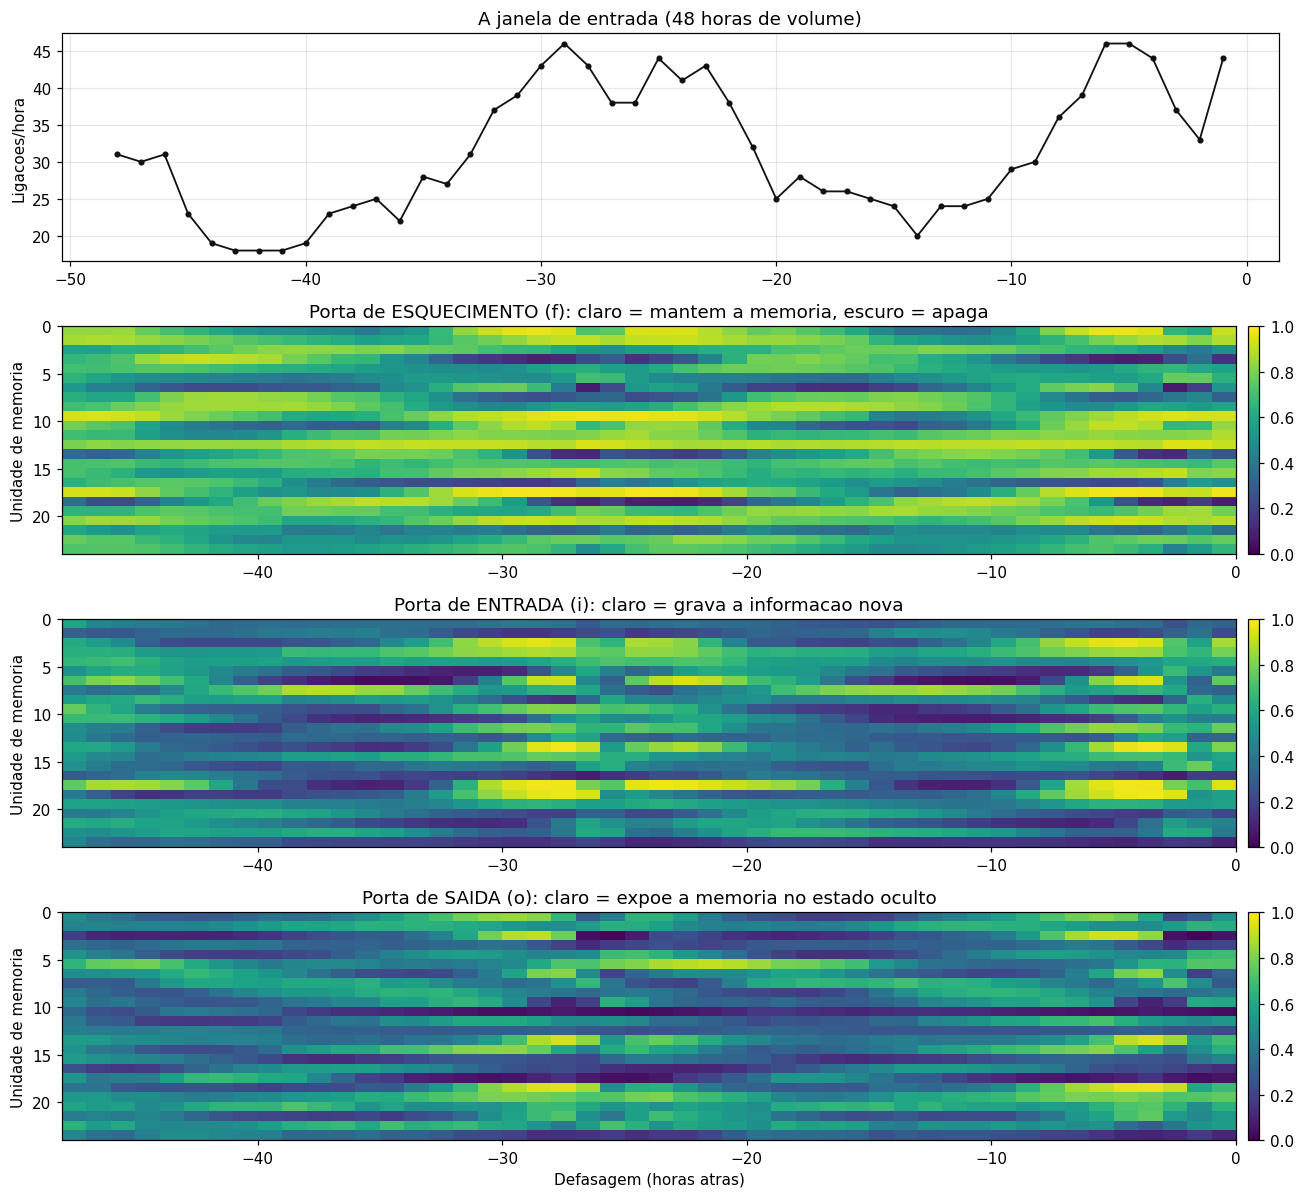

Porta de esquecimento: media geral 0.641  |  por unidade, varia de 0.41 a 0.89
  unidades com f medio > 0,7 (seguram memoria longa): 10 de 24
  unidades com f medio < 0,5 (esquecem rapido)      : 4 de 24
Porta de entrada     : media 0.454  |  amplitude maxima em uma unidade: 0.92
Porta de saida       : media 0.424
Estado de celula     : varia de -7.99 a 2.69


In [17]:
# Os portoes em acao: uma janela real, todas as 24 unidades
exemplo = N_teste[500:501]
_, cache_lstm = lstm.frente(exemplo)
portas_f = np.array([passo[1][0] for passo in cache_lstm["cache"]])     # (48, 24)
portas_i = np.array([passo[2][0] for passo in cache_lstm["cache"]])
portas_o = np.array([passo[4][0] for passo in cache_lstm["cache"]])
celula = np.array([passo[6][0] for passo in cache_lstm["cache"]])

fig, eixos = plt.subplots(4, 1, figsize=(12, 11))
eixos[0].plot(np.arange(-JANELA, 0), X_teste[500, :, 0], color="#111111", marker=".", lw=1.2)
eixos[0].set_title("A janela de entrada (48 horas de volume)")
eixos[0].set_ylabel("Ligacoes/hora")

for ax, dados, titulo, mapa in (
        (eixos[1], portas_f.T, "Porta de ESQUECIMENTO (f): claro = mantem a memoria, escuro = apaga", "viridis"),
        (eixos[2], portas_i.T, "Porta de ENTRADA (i): claro = grava a informacao nova", "viridis"),
        (eixos[3], portas_o.T, "Porta de SAIDA (o): claro = expoe a memoria no estado oculto", "viridis")):
    im = ax.imshow(dados, aspect="auto", cmap=mapa, vmin=0, vmax=1,
                   extent=[-JANELA, 0, 24, 0], interpolation="nearest")
    ax.set_title(titulo); ax.set_ylabel("Unidade de memoria"); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
eixos[3].set_xlabel("Defasagem (horas atras)")
plt.tight_layout(); plt.show()

media_f_unidade = portas_f.mean(axis=0)
print(f"Porta de esquecimento: media geral {portas_f.mean():.3f}  |  por unidade, varia de "
      f"{media_f_unidade.min():.2f} a {media_f_unidade.max():.2f}")
print(f"  unidades com f medio > 0,7 (seguram memoria longa): {int((media_f_unidade > 0.7).sum())} de 24")
print(f"  unidades com f medio < 0,5 (esquecem rapido)      : {int((media_f_unidade < 0.5).sum())} de 24")
print(f"Porta de entrada     : media {portas_i.mean():.3f}  |  amplitude maxima em uma unidade: "
      f"{(portas_i.max(0) - portas_i.min(0)).max():.2f}")
print(f"Porta de saida       : media {portas_o.mean():.3f}")
print(f"Estado de celula     : varia de {celula.min():.2f} a {celula.max():.2f}")

> **Lendo os mapas de calor.** Cada mapa tem o **tempo no eixo horizontal** (48 horas, da mais antiga à mais recente) e as **24 unidades de memória no eixo vertical**. Claro significa portão aberto (próximo de 1) e escuro, fechado (próximo de 0). Estamos literalmente olhando a rede decidir o que lembrar.
>
> A leitura mais importante é a **heterogeneidade entre as linhas**, que aparece como um padrão de **faixas horizontais**. As unidades **não fazem a mesma coisa**, e essa especialização emergiu do treinamento, não foi programada:
>
> - Na **porta de esquecimento**, o valor médio por unidade varia de **0,41 a 0,89**. As **10 unidades com média acima de 0,7** formam as faixas claras contínuas: são as de **memória longa**, que seguram informação ao longo de toda a janela e são candidatas naturais a estar rastreando o nível de surto. As de média mais baixa aparecem como faixas escuras e oscilam com o ritmo do dia, esquecendo e recomeçando: são detectores de fase.
> - Na **porta de entrada**, aparecem **faixas verticais mais claras** em certos instantes, sobretudo em torno de 30 e de 27 horas atrás e nas últimas horas. Ali a rede decidiu que **aquela hora específica trazia informação nova** que valia gravar. Uma unidade chega a variar **0,92** entre o seu mínimo e o seu máximo ao longo da janela: é um portão que realmente abre e fecha, e não um valor fixo.
> - A **porta de saída** tem média de **0,42**: a rede mantém na célula bastante informação que **não** expõe no estado oculto a cada passo, e revela apenas o que é relevante para o instante. É a diferença entre o que ela sabe e o que ela diz.
>
> É este o sentido prático de "abrir a caixa preta" em uma LSTM. Não conseguimos a leitura direta que tínhamos nos pesos do perceptron ou nas regras da árvore de decisão, mas também não estamos diante de algo opaco: é possível identificar quais unidades sustentam memória longa e em que instantes a rede decidiu aprender algo novo.


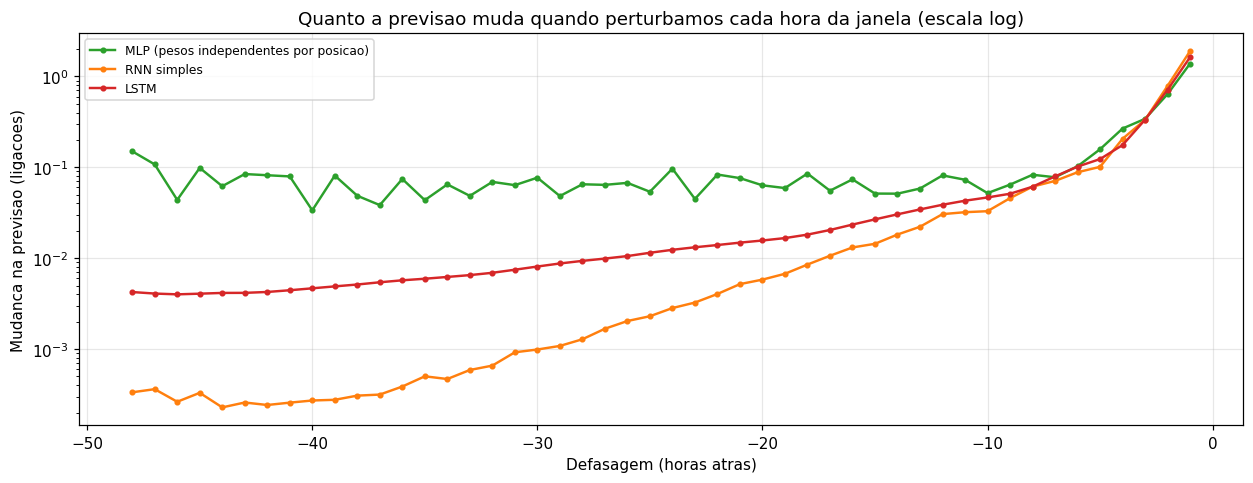

,arquitetura,ultima hora,6 horas atras,24 horas atras,47 horas atras,soma alem de 24h
0,MLP,1.383,0.103,0.0964,0.1498,1.647
1,RNN simples,1.903,0.088,0.0028,0.0003,0.016
2,LSTM,1.627,0.102,0.0124,0.0042,0.150


In [18]:
# Sensibilidade da previsao a cada posicao da janela: quem realmente olha para tras?
amostra = N_teste[:600]

def perfil_sensibilidade(modelo, achatar=False):
    """Perturba cada posicao da janela e mede quanto a previsao muda, em ligacoes."""
    entrada = amostra.reshape(len(amostra), -1) if achatar else amostra
    base = modelo.frente(entrada)[0]
    perfil = []
    for j in range(JANELA):
        Z = amostra.copy()
        Z[:, j, 0] += 0.5                                  # meio desvio-padrao naquela hora
        Zin = Z.reshape(len(Z), -1) if achatar else Z
        perfil.append(float(np.mean(np.abs(modelo.frente(Zin)[0] - base))) * desvio)
    return np.array(perfil)

sens_mlp = perfil_sensibilidade(mlp, achatar=True)
sens_rnn = perfil_sensibilidade(rnn)
sens_lstm = perfil_sensibilidade(lstm)

fig, ax = plt.subplots(figsize=(11.5, 4.5))
lags = np.arange(-JANELA, 0)
for perfil, nome, cor in ((sens_mlp, "MLP (pesos independentes por posicao)", "#2ca02c"),
                          (sens_rnn, "RNN simples", "#ff7f0e"),
                          (sens_lstm, "LSTM", "#d62728")):
    ax.semilogy(lags, np.maximum(perfil, 1e-5), marker="o", ms=3, color=cor, lw=1.6, label=nome)
ax.set_title("Quanto a previsao muda quando perturbamos cada hora da janela (escala log)")
ax.set_xlabel("Defasagem (horas atras)"); ax.set_ylabel("Mudanca na previsao (ligacoes)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

tabela_sens = pd.DataFrame({
    "arquitetura": ["MLP", "RNN simples", "LSTM"],
    "ultima hora": [round(s[-1], 3) for s in (sens_mlp, sens_rnn, sens_lstm)],
    "6 horas atras": [round(s[-6], 3) for s in (sens_mlp, sens_rnn, sens_lstm)],
    "24 horas atras": [round(s[-24], 4) for s in (sens_mlp, sens_rnn, sens_lstm)],
    "47 horas atras": [round(s[0], 4) for s in (sens_mlp, sens_rnn, sens_lstm)],
    "soma alem de 24h": [round(s[:24].sum(), 3) for s in (sens_mlp, sens_rnn, sens_lstm)],
})
tabela_sens

> **Lendo o gráfico.** Este experimento responde a uma pergunta direta: **até onde no passado cada arquitetura realmente olha?** Perturbamos meio desvio-padrão em uma hora específica da janela e medimos quanto a previsão se move.
>
> Todas as três concordam no essencial: a **última hora domina**, com sensibilidade em torno de 1,4 a 1,9 ligação. Isso é correto e esperado, porque a série tem forte persistência de curto prazo.
>
> A diferença aparece no passado distante, e é aí que o eixo logarítmico ganha valor:
>
> - A **RNN simples** (laranja) despenca. Em 24 horas atrás, sua sensibilidade é de **0,0028**, e em 47 horas, **0,0003**. Somando tudo além de 24 horas, ela reage com **0,016**. Traduzindo: para a RNN, **a primeira metade da janela praticamente não existe**. É o gradiente que desaparece, agora medido no modelo treinado e não em teoria.
> - A **LSTM** (vermelha) mantém **0,150** de sensibilidade acumulada além de 24 horas, cerca de **dez vezes mais** do que a RNN. A esteira de memória funcionou.
> - O **MLP** (verde) mostra a maior sensibilidade distante de todas, **1,647**. Mas atenção, porque a leitura aqui é diferente: o MLP não tem memória, ele tem **acesso direto** a todas as posições com pesos independentes. Parte dessa sensibilidade é informação legítima (ele encontrou os lags de 24 e 48 horas, como o perceptron); parte é **ruído aprendido**, pesos que se ajustaram a padrões espúrios porque havia 288 deles para ajustar. Sensibilidade alta não é o mesmo que informação usada com proveito, e é justamente por isso que o MLP, com muito mais parâmetros e mais acesso, termina **atrás** da LSTM.


## Comparação final: da regressão linear à memória de longo prazo


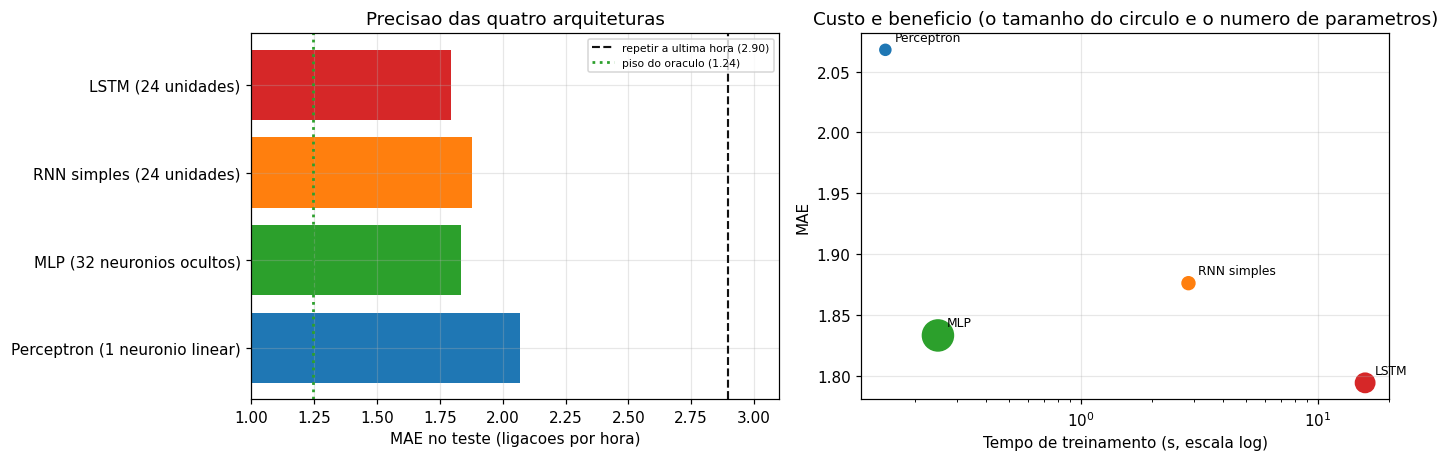

,modelo,parametros,tempo (s),MAE,RMSE,MAPE (%),% do sinal aprendivel
0,Repetir a ultima hora (lag 1),0,0.0,2.896,3.662,13.98,0.0%
1,Mesma hora de ontem (lag 24),0,0.0,4.508,5.995,28.35,0.0%
2,Perceptron (1 neuronio linear),289,0.1,2.068,2.650,11.52,50.1%
3,MLP (32 neuronios ocultos),9281,0.2,1.833,2.331,10.50,64.3%
4,RNN simples (24 unidades),769,2.8,1.876,2.418,10.93,61.7%
5,LSTM (24 unidades),3001,15.8,1.794,2.315,9.61,66.7%
6,ORACULO (piso do problema),0,0.0,1.243,1.558,6.34,100.0%


In [19]:
placar = []
for nome, previsao, n_par, tempo in [
        ("Repetir a ultima hora (lag 1)", X_teste[:, -1, 0], 0, 0.0),
        ("Mesma hora de ontem (lag 24)", X_teste[:, -24, 0], 0, 0.0),
        ("Perceptron (1 neuronio linear)", perceptron.frente(F_teste)[0] * desvio + media, n_par_perc, tempo_perc),
        ("MLP (32 neuronios ocultos)", mlp.frente(F_teste)[0] * desvio + media, n_par_mlp, tempo_mlp),
        ("RNN simples (24 unidades)", rnn.frente(N_teste)[0] * desvio + media, n_par_rnn, tempo_rnn),
        ("LSTM (24 unidades)", lstm.frente(N_teste)[0] * desvio + media, n_par_lstm, tempo_lstm),
        ("ORACULO (piso do problema)", sinal[corte2:], 0, 0.0)]:
    mae, rmse, mape = metricas(y_teste, previsao)
    placar.append({"modelo": nome, "parametros": n_par, "tempo (s)": round(tempo, 1),
                   "MAE": round(mae, 3), "RMSE": round(rmse, 3), "MAPE (%)": round(mape, 2)})

placar = pd.DataFrame(placar)
mae_base, mae_piso = placar.MAE.iloc[0], placar.MAE.iloc[-1]
placar["% do sinal aprendivel"] = ((100 * (mae_base - placar.MAE) / (mae_base - mae_piso))
                                   .round(1).clip(lower=0).astype(str) + "%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3))
modelos = placar.iloc[2:6]
ax1.barh(modelos.modelo, modelos.MAE, color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"])
ax1.axvline(mae_base, color="#111111", ls="--", lw=1.4, label=f"repetir a ultima hora ({mae_base:.2f})")
ax1.axvline(mae_piso, color="#2ca02c", ls=":", lw=1.8, label=f"piso do oraculo ({mae_piso:.2f})")
ax1.set_xlim(1.0, 3.1); ax1.set_xlabel("MAE no teste (ligacoes por hora)")
ax1.set_title("Precisao das quatro arquiteturas"); ax1.legend(fontsize=7)

ax2.scatter(modelos["tempo (s)"] + 0.05, modelos.MAE, s=modelos.parametros / 25 + 40,
            color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"])
for _, linha in modelos.iterrows():
    ax2.annotate(linha.modelo.split(" (")[0], (linha["tempo (s)"] + 0.05, linha.MAE),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)
ax2.set_xscale("log"); ax2.set_xlabel("Tempo de treinamento (s, escala log)")
ax2.set_ylabel("MAE"); ax2.set_title("Custo e beneficio (o tamanho do circulo e o numero de parametros)")
plt.tight_layout(); plt.show()

placar

> **Lendo a tabela.** Cinco leituras, em ordem de importância.
>
> **A escada funciona.** Cada acréscimo de arquitetura melhorou o resultado: perceptron **2,07**, MLP **1,83**, LSTM **1,79**. Em relação a repetir a última hora (2,90), a LSTM capturou **67% de todo o sinal aprendível** que existia entre a referência e o piso de 1,24.
>
> **A LSTM ganha, e por pouco.** A diferença entre LSTM (1,794) e MLP (1,833) é de **0,04 ligação por hora**, cerca de 2%. Em termos operacionais, ninguém dimensiona uma escala de atendentes de forma diferente por causa disso. É preciso dizer isso com clareza, porque é a informação que decide se o projeto vai para produção.
>
> **A eficiência conta uma história diferente da precisão.** A LSTM usa **3.001 parâmetros** contra 9.281 do MLP: um terço, com resultado melhor. Se o critério fosse acurácia por parâmetro, a diferença seria expressiva. E a RNN é a mais econômica de todas, com 769 parâmetros para MAE de 1,88.
>
> **O tempo é o preço.** O painel da direita coloca tempo no eixo horizontal, em escala logarítmica, e mostra o formato do trade-off: o MLP está no canto barato e bom; a LSTM, no canto caro e um pouco melhor. **Setenta vezes mais tempo** para 2% de MAE. Em uma central com previsão recalculada de hora em hora, essa conta pode até fechar; em um projeto com prazo curto e equipe pequena, não fecha.
>
> **O piso continua mandando.** Nenhuma arquitetura chega perto de 1,24, e nenhuma chegará: o que falta é ruído de observação. Aqui, como no notebook anterior, o esforço que realmente derrubaria o erro não é arquitetural, é obter **dados novos** (o número de atendentes em linha, o volume de campanhas ativas, o boletim epidemiológico oficial).


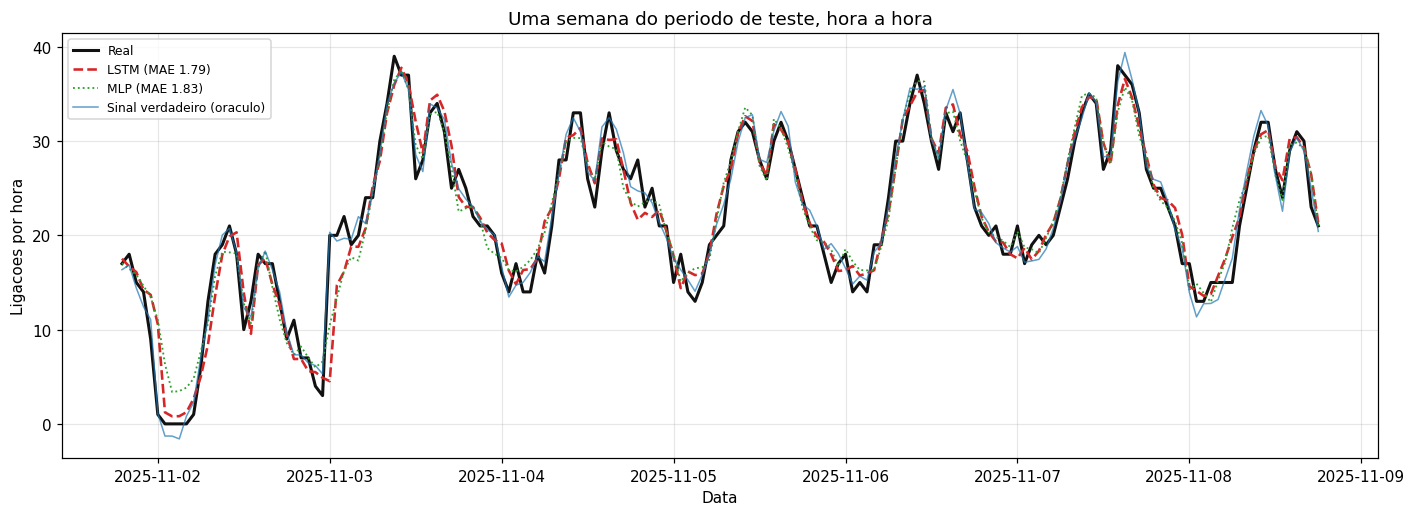

MAE da LSTM por faixa de hora:
  madrugada (0h-5h) : 1.93
  manha (6h-11h)    : 1.76
  tarde (12h-17h)   : 1.73
  noite (18h-23h)   : 1.75

Vies medio do residuo: -0.252 ligacao (perto de zero = sem vies sistematico)


In [20]:
inicio_semana = 1200
fim_semana = inicio_semana + 168
fatia = slice(inicio_semana, fim_semana)
eixo = datas[corte2:][fatia]

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(eixo, y_teste[fatia].ravel(), color="#111111", lw=2, label="Real")
ax.plot(eixo, lstm.frente(N_teste[fatia])[0].ravel() * desvio + media, color="#d62728",
        lw=1.7, ls="--", label=f"LSTM (MAE {mae_lstm:.2f})")
ax.plot(eixo, mlp.frente(F_teste[fatia])[0].ravel() * desvio + media, color="#2ca02c",
        lw=1.2, ls=":", label=f"MLP (MAE {mae_mlp:.2f})")
ax.plot(eixo, sinal[corte2:][fatia].ravel(), color="#1f77b4", lw=1.0, alpha=0.7,
        label="Sinal verdadeiro (oraculo)")
ax.set_title("Uma semana do periodo de teste, hora a hora")
ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por hora"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

residuo = y_teste.ravel() - (lstm.frente(N_teste)[0].ravel() * desvio + media)
hora_teste = datas[corte2:].hour
erro_por_hora = pd.Series(np.abs(residuo)).groupby(hora_teste).mean()
print("MAE da LSTM por faixa de hora:")
print(f"  madrugada (0h-5h) : {erro_por_hora.loc[0:5].mean():.2f}")
print(f"  manha (6h-11h)    : {erro_por_hora.loc[6:11].mean():.2f}")
print(f"  tarde (12h-17h)   : {erro_por_hora.loc[12:17].mean():.2f}")
print(f"  noite (18h-23h)   : {erro_por_hora.loc[18:23].mean():.2f}")
print(f"\nVies medio do residuo: {residuo.mean():+.3f} ligacao (perto de zero = sem vies sistematico)")

> **Lendo o gráfico.** Uma semana de teste, hora a hora. A linha preta é o real, a azul clara é o **sinal verdadeiro** (o que o oráculo veria) e as duas tracejadas são as previsões.
>
> O primeiro ponto é que ambas as redes **acompanham a forma do dia com fidelidade**: subida da manhã, vale do almoço, platô da tarde, queda da noite, e o degrau do fim de semana. O segundo é mais interessante: as previsões passam **muito perto da linha azul do sinal**, e a distância que sobra até a linha preta é, em boa medida, o ruído de observação. Visualmente, isso é o piso do problema.
>
> O erro por faixa de hora traz um resultado que contraria a intuição e vale comentar: ele é **praticamente uniforme ao longo do dia**, entre **1,73 e 1,93**, com a **madrugada ligeiramente pior** do que os horários de pico. Seria natural esperar o contrário, já que a variância absoluta cresce com o nível. Um perfil de erro plano é, na verdade, uma boa notícia: significa que o modelo não tem um período do dia em que falha de forma sistemática, e que a escala pode ser dimensionada com a mesma confiança em qualquer turno.
>
> O **viés médio do resíduo é de -0,25 ligação**, cerca de 1% do nível médio. É pequeno, mas não é zero: a rede subestima ligeiramente. Vale a comparação com o notebook anterior, em que o viés agregado era o problema central. Aqui, com 0,25 ligação por hora, somar as 24 horas do dia acumularia cerca de 6 ligações em um volume diário de aproximadamente 600, o que é perfeitamente utilizável para planejamento.


### Previsão de várias horas à frente

Até aqui prevemos **uma hora à frente**. A operação, no entanto, precisa da escala do dia inteiro montada com antecedência. A forma mais simples de estender o horizonte é a **previsão recursiva**: prever a próxima hora, **inserir a própria previsão** na janela como se fosse um dado observado, e repetir.

O risco é evidente e tem nome: **acumulação de erro**. A partir do segundo passo, a rede está olhando para os seus próprios erros. Vamos medir o tamanho do estrago.


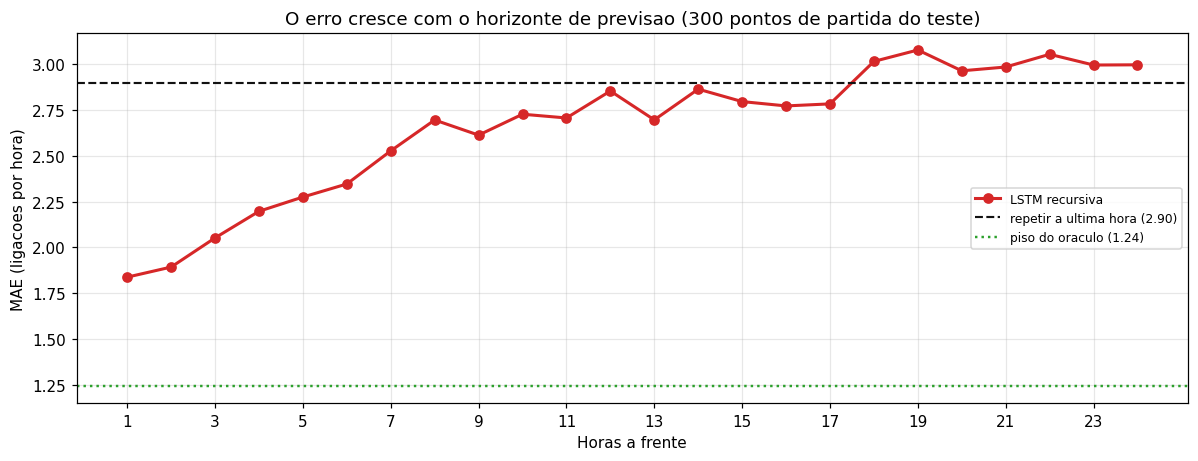

   1 hora(s) a frente: MAE 1.84
   3 hora(s) a frente: MAE 2.05
   6 hora(s) a frente: MAE 2.35
  12 hora(s) a frente: MAE 2.85
  24 hora(s) a frente: MAE 3.00


In [21]:
g_inicios = np.random.default_rng(3)
inicios = g_inicios.integers(0, len(N_teste) - 25, 300)
HORIZONTE = 24
erros_horizonte = np.zeros((len(inicios), HORIZONTE))

for a, ini in enumerate(inicios):
    janela = N_teste[ini].copy()
    for passo in range(HORIZONTE):
        previsto = float(lstm.frente(janela[None, :, :])[0][0, 0])
        erros_horizonte[a, passo] = abs((previsto * desvio + media) - y_teste[ini + passo, 0])
        # avanca a janela: entra a PREVISAO no canal de valor e o calendario REAL da hora seguinte
        calendario = N_teste[ini + passo + 1, -1, 1:] if ini + passo + 1 < len(N_teste) else janela[-1, 1:]
        nova_linha = np.concatenate([[previsto], calendario])
        janela = np.concatenate([janela[1:], nova_linha[None, :]], axis=0)

mae_horizonte = erros_horizonte.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 4.3))
ax.plot(range(1, HORIZONTE + 1), mae_horizonte, marker="o", color="#d62728", lw=2,
        label="LSTM recursiva")
ax.axhline(mae_base, color="#111111", ls="--", lw=1.4, label=f"repetir a ultima hora ({mae_base:.2f})")
ax.axhline(mae_piso, color="#2ca02c", ls=":", lw=1.6, label=f"piso do oraculo ({mae_piso:.2f})")
ax.set_title("O erro cresce com o horizonte de previsao (300 pontos de partida do teste)")
ax.set_xlabel("Horas a frente"); ax.set_ylabel("MAE (ligacoes por hora)")
ax.set_xticks(range(1, 25, 2)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for h in (1, 3, 6, 12, 24):
    print(f"  {h:2d} hora(s) a frente: MAE {mae_horizonte[h-1]:.2f}")

> **Lendo o gráfico.** A curva conta uma história em três atos.
>
> **De 1 a 3 horas**, o erro é baixo (**1,84** e **2,05**) e a previsão é confiável. É a janela útil para decisões de curtíssimo prazo, como remanejar atendentes dentro do turno.
>
> **De 6 a 12 horas**, o erro cresce para **2,35 e 2,85**, chegando ao patamar de repetir a última hora. A informação de curto prazo, que dominava a previsão de um passo, já se esgotou.
>
> **A partir de 12 horas**, a curva **satura** em torno de **3,0** e para de piorar. Isso é importante e não é óbvio: significa que a rede não entrou em espiral. Ela perdeu a memória do estado recente, mas continua ancorada nos canais de **calendário**, que continuam sendo alimentados com valores reais (a hora e o dia da semana das horas futuras são conhecidos). Ou seja, no horizonte longo o modelo degrada para algo próximo de "prever o perfil típico daquela hora", que é uma previsão razoável e não um desastre.
>
> A lição prática é que **o horizonte útil de um modelo recursivo é curto**, e que para prever o dia inteiro existem alternativas melhores: treinar um modelo com **saída múltipla** (24 valores de uma vez, o que evita a realimentação de erro) ou usar um modelo de série temporal com sazonalidade explícita, como o SARIMA e o Prophet das Seções 3 e 4. Cada horizonte pede a sua ferramenta.


### Laboratório interativo: veja a LSTM aprendendo

Guardamos **fotografias** dos pesos da LSTM ao final das épocas 1, 3, 7 e 15. Mova o controle e veja a mesma rede, na mesma semana de teste, em quatro momentos do seu treinamento.

O que observar: na **época 1** a rede já capturou o nível geral, mas o ciclo diário está achatado, com picos baixos e vales altos. Ao avançar para as épocas 3 e 7, os picos ganham amplitude e o vale da madrugada se aprofunda. Na **época 15** a curva prevista já acompanha o real de perto. Aprender, aqui, é ir dos traços grossos para os detalhes: primeiro o nível, depois o ritmo, depois a amplitude.


In [22]:
try:
    from ipywidgets import interact, SelectionSlider
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False

pesos_finais = {k: v.copy() for k, v in lstm.p.items()}

def ver_aprendizado(epoca=1):
    for k, v in fotos[epoca].items():
        lstm.p[k] = v.copy()
    previsto_total = lstm.frente(N_teste)[0] * desvio + media
    mae_epoca = metricas(y_teste, previsto_total)[0]
    for k, v in pesos_finais.items():
        lstm.p[k] = v.copy()                                  # devolve os pesos finais

    fig, ax = plt.subplots(figsize=(12, 4.3))
    ax.plot(eixo, y_teste[fatia].ravel(), color="#111111", lw=1.8, label="Real")
    ax.plot(eixo, previsto_total[fatia].ravel(), color="#d62728", lw=1.7, ls="--",
            label=f"LSTM apos {epoca} epoca(s)")
    ax.set_ylim(0, max(y_teste[fatia]) * 1.15)
    ax.set_title(f"Fotografia da epoca {epoca}   |   MAE no teste = {mae_epoca:.3f}   "
                 f"(modelo final: {mae_lstm:.3f})")
    ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por hora"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

if _INTERATIVO:
    interact(ver_aprendizado, epoca=SelectionSlider(options=sorted(fotos), value=1, description="Epoca"))
else:
    print("ipywidgets indisponivel; exibindo a primeira e a ultima fotografia.")
    ver_aprendizado(1)
    ver_aprendizado(15)

interactive(children=(SelectionSlider(description='Epoca', options=(1, 3, 7, 15), value=1), Output()), _dom_cl…

> **O que observar.** Na época 1 a previsão é uma versão **amortecida** da realidade: o formato está lá, mas a amplitude é pequena, como se a rede estivesse com o volume baixo. Isso é típico do início do treinamento com erro quadrático: quando a rede ainda não confia no sinal, a estratégia que minimiza a perda é **encolher em direção à média**. Ao longo das épocas, os picos crescem e os vales descem, e o MAE cai monotonamente.
>
> Esse comportamento tem um nome informal no dia a dia de quem treina modelos de previsão: **regressão à média por subtreino**. Se você entregar um modelo cujas previsões parecem sistematicamente achatadas em relação ao real, o diagnóstico mais provável não é falta de features, é **falta de treinamento**.


## Síntese, custo e benefício, e onde isso entra na operação

Esta aula construiu a família das redes neurais do zero, sem nenhuma biblioteca de deep learning, aplicada à previsão horária do volume da central de atendimento.

**A escada que percorremos:**

| Arquitetura           | Ideia central                                        | Parâmetros | MAE      |
| --------------------- | ---------------------------------------------------- | ---------- | -------- |
| Repetir a última hora | nenhuma                                              | 0          | 2,90     |
| **Perceptron**        | soma ponderada de todas as entradas (é um AR linear) | 289        | 2,07     |
| **MLP**               | camada oculta acrescenta não linearidade             | 9.281      | 1,83     |
| **RNN**               | pesos compartilhados no tempo e estado que atravessa | 769        | 1,88     |
| **LSTM**              | esteira de memória somada, com três portões          | 3.001      | **1,79** |
| Oráculo               | conhece o sinal, não conhece o ruído                 | -          | 1,24     |

**Os cinco conceitos para levar:**

1. **Um neurônio é uma soma ponderada mais uma ativação.** Sem a ativação não linear, uma rede inteira colapsa em uma regressão linear.
2. **A derivada da ativação é o que viaja na retropropagação**, e ela é sempre menor ou igual a 1. Multiplicada muitas vezes, some.
3. **A rede densa ignora a ordem.** Provamos isso embaralhando a janela sem nenhuma perda de desempenho.
4. **A recorrência resolve a ordem, mas cria o problema do gradiente.** A RNN é elegante e econômica, e cega para além de umas 20 posições.
5. **A LSTM troca multiplicação por soma na memória.** Os três portões decidem o que esquecer, o que gravar e o que revelar, e o resultado é uma via em que o gradiente atravessa dezenas de passos. A tarefa de memória mostrou a diferença de forma inequívoca: 100% contra 52% de acerto com 34 passos de defasagem.

**Quando usar LSTM na operadora, e quando não usar.** Sejamos diretos, porque este é o julgamento profissional que a aula prepara.

**Use** quando houver **estado latente com persistência longa** que não se codifica em colunas (ondas epidemiológicas, adoção gradual de um novo serviço, mudanças de comportamento de uso), quando houver **muito histórico** (anos de dados em granularidade fina) e quando o ganho de precisão tiver **valor financeiro claro**, como no dimensionamento de escala de uma central grande, em que 2% de erro a menos são horas de atendente por mês.

**Não use** quando o histórico for curto (séries mensais de sinistralidade, com poucas dezenas de pontos, são o caso clássico onde a LSTM é a pior escolha possível), quando o problema for **tabular com muitas variáveis categóricas** (ali o boosting da aula anterior ganha em precisão, em tempo e em interpretabilidade), quando a **explicabilidade for requisito regulatório**, ou quando a equipe não tiver quem mantenha o modelo. Não existe prêmio por usar a ferramenta mais sofisticada.

**Limitações que precisam ficar registradas:**

- **Custo computacional.** Sessenta vezes o tempo do MLP nesta base, e o laço temporal é intrinsecamente sequencial.
- **Exige normalização e é sensível a hiperparâmetros.** Taxa de aprendizado, inicialização e número de épocas mudam o resultado. Diferente das árvores, aqui não há configuração padrão confiável.
- **Interpretabilidade limitada.** Conseguimos inspecionar portões e medir sensibilidade, mas não há nada comparável à leitura direta de uma regra de árvore.
- **Não extrapola tendência de longo prazo**, exatamente como as árvores. Redes recorrentes trabalham em torno da faixa de valores que viram.
- **A memória não é infinita.** Além de umas quatro dezenas de passos, a própria LSTM começa a falhar, o que motivou os mecanismos de atenção e os Transformers.

**Fechando o módulo F1.** Percorremos cinco famílias: os fundamentos estatísticos (Seção 2), ARIMA e SARIMA (Seção 3), Prophet (Seção 4), árvores e ensembles (Seções 5 a 8) e redes neurais (Seção 9). O erro caiu em cada etapa, e em nenhuma delas a família mais sofisticada venceu por uma margem confortável. A conclusão que vale levar para a prática profissional é a da Seção 10 da apostila: **treine dois ou três candidatos de famílias diferentes, avalie fora da amostra contra referências simples, conheça o piso de erro do seu problema e escolha considerando precisão, custo e explicabilidade juntos**. O modelo que vai para produção é o que a operação consegue confiar e manter, e não o que ganha por dois centésimos em uma tabela.

---

**Referências**

- Rosenblatt, F. (1958). The perceptron: a probabilistic model for information storage and organization in the brain. _Psychological Review_.
- Rumelhart, D. E.; Hinton, G. E.; Williams, R. J. (1986). Learning representations by back-propagating errors. _Nature_.
- Bengio, Y.; Simard, P.; Frasconi, P. (1994). Learning long-term dependencies with gradient descent is difficult. _IEEE Transactions on Neural Networks_.
- Hochreiter, S.; Schmidhuber, J. (1997). Long Short-Term Memory. _Neural Computation_, v. 9, n. 8.
- Kingma, D. P.; Ba, J. (2015). Adam: A Method for Stochastic Optimization. _ICLR_.
- Chacón, H. et al. (2018). Forecasting call center arrivals using temporal memory networks.
- Chen, W.; Li, J. (2023). Forecasting teleconsultation demand using an ensemble CNN attention-based BiLSTM model.
- Goodfellow, I.; Bengio, Y.; Courville, A. (2016). _Deep Learning_. MIT Press.
